# Fase 2 a parità di condizioni — lente Jacobiana vs **TAM** vs **ERCR** (LLaVA-1.5-7B, VQAv2 sample + COCO annotations)

Questo notebook esegue **gli esperimenti della Parte 2** di `Esperimenti-Michele.ipynb`
(pointing game, deletion, insertion) sui **due metodi di confronto**, con il tuo identico protocollo.
È pensato per essere **lanciato tutto di seguito**: config → modello → dati → mappe → loop di
valutazione → grafici, con salvataggio incrementale a ogni immagine.

| metodo | origine | come nasce la mappa |
|---|---|---|
| `TAM (ECI+RGF)` | `TAM_prompt.ipynb` | $\mathrm{ReLU}$ dei logit del token oggetto, meno l'interferenza dei token precedenti del prompt stimata via ECI, poi Rank Gaussian Filter |
| `ERCR` | `Evidence_Recomposition_ERCR_fedele.ipynb` | logit-lens multi-scala ricomposta (ER), meno il contesto predittivo pesato via RBO e proiettato con $\beta_t$ (PCR), poi rank-Gaussian |

Le lenti Jacobiane **non vengono ricalcolate né salvate da questo notebook**. Vengono caricate in sola lettura da
`../Corretto/jlens_llm_cache_J_Shared100/lenses.pt`. Gli output dell’esperimento vengono invece salvati
esclusivamente nella sottocartella `task2_compare_TAM_ERCR/` dentro `XAI_VQA`.

**Cosa resta identico** (è ciò che rende il confronto onesto): modello LLaVA-1.5-7B in 4-bit sullo
stesso device, `miguelcarv/VQAv2_sample_areas` split `validation`, deduplicato per `image_id`, con le **prime 1000 immagini uniche
nello stesso ordine del dataset**, stessi oggetti (categorie COCO single-token e con bbox, max 3 per immagine),
stessa griglia 24×24, stessa occlusione con patch neri 14×14 su `pixel_values`, stesso
`SCORE_MODE="generate"` con `DESCRIBE_Q` e `MAX_NEW_EVAL=24`, stessi `OCC_STEPS=10` / `N_EVAL=500`,
stessa proiezione bbox→canvas 336, stesse metriche, stessa AUC trapezoidale, stesso formato di
salvataggio (`task2_partial.pt` con le chiavi `point / del_auc / ins_auc / del_curve / ins_curve`) e
**gli stessi tre grafici**.

**Cosa cambia**: solo la funzione che produce la mappa 24×24. Il loop calcola le mappe di *tutti* i
metodi sulla stessa coppia (immagine, oggetto) prima di occludere e, se un metodo fallisce, scarta
l'oggetto per tutti: gli `n` in tabella devono coincidere.

---
### Adattamenti necessari (entrambi i metodi nascono su Qwen2-VL, immagine singola)

**TAM.** Portato su LLaVA-1.5: i visual token sono i 576 token `<image>`, la griglia è 24×24 fissa
(non serve `image_grid_thw`), la proiezione al vocabolario è `LM_HEAD(FINAL_NORM(h))`. Via
`qwen_vl_utils`, il chat template Qwen e `cv2`. Resta la variante **sequenziale sui token del
prompt** (un solo forward, ordine causale dato dalla posizione nel prompt).

**ERCR.** Portato su LLaVA-1.5 con tre adattamenti sostanziali, spiegati per esteso nelle note finali:
1. l'operatore di riallineamento $\Omega_m$ **degenera all'identità**, perché il processor CLIP di
   LLaVA porta qualunque input a 336×336 → sempre 24×24 patch. Le viste multi-scala restano
   informative (cambia il dettaglio effettivo, non la geometria), ma ER qui è un ensemble di
   risoluzioni, non di griglie;
2. ERCR spiega un token **della risposta**: per avere l'oggetto che ci serve la risposta viene
   **forzata** (`"The image contains a {obj}."`) invece che generata, con forward teacher-forced.
   È lo stesso meccanismo del notebook originale, che è già teacher-forced sui token generati;
3. la sua valutazione nativa (fixed-prefix deletion/insertion con baseline blur) è sostituita dal
   tuo protocollo di occlusione, che è il punto dell'esercizio.

In [ ]:
1

# Parte 0 — Motore (da `Esperimenti-Michele.ipynb`, solo il necessario alla fase 2)

Config, modello, `Recorder`/`build_inputs`, caricamento delle lenti $J^V,J^T$ e loader `miguelcarv/VQAv2_sample_areas` con bounding box COCO. Rispetto all'originale ho tolto ciò che serve solo alla Parte 1 (hook di editing,
`generate` con steering, `patch_readout`). Restano `DESCRIBE_Q` e `mentions`, usati dallo scoring.

In [4]:
# 0.1 — Config (identica all'originale; in fondo le aggiunte per questo notebook)
import os, re, math, random, zlib
from contextlib import contextmanager
from io import BytesIO

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ---- modello / device ----
DEVICE   = "cuda:1"          # <-- cambia se serve
MODEL_ID = "llava-hf/llava-1.5-7b-hf"
USE_4BIT = True
DTYPE    = torch.bfloat16

# ---- fit delle lenti (come nell'originale) ----
SOURCE_LAYERS = list(range(2, 32, 4))   # [2,6,10,14,18,22,26,30] -> layer con Jacobiano
N_FIT_IMAGES  = 100                     # immagini per stimare le lenti
DIM_BATCH     = 4                       # righe di cotangenti per backward (memoria)
NORM_SIGMA    = 4.0                     # scarta posizioni visive ad alta norma
TARGET_MODE   = "question"              # "question" | "all"

# ---- dataset di analisi (VQAv2 sample con annotazioni COCO) ----
DATASET_ID  = "miguelcarv/VQAv2_sample_areas"
SPLIT       = "validation"

# ---- cartelle del progetto ----
# Il notebook vive in VLM-TOMM/Prove/J/XAI_VQA/.
# Risolviamo XAI_VQA anche se Jupyter e' stato avviato da J/ o dalla root VLM-TOMM/.
from pathlib import Path

def _resolve_xai_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "XAI_VQA",
        cwd / "Prove" / "J" / "XAI_VQA",
        cwd / "VLM-TOMM" / "Prove" / "J" / "XAI_VQA",
    ]
    for parent in cwd.parents:
        candidates.extend([
            parent / "XAI_VQA",
            parent / "Prove" / "J" / "XAI_VQA",
            parent / "VLM-TOMM" / "Prove" / "J" / "XAI_VQA",
        ])
    seen = set()
    for p in candidates:
        p = p.resolve()
        if p in seen:
            continue
        seen.add(p)
        if p.name == "XAI_VQA" and p.is_dir() and (p.parent / "Corretto").is_dir():
            return p
    raise FileNotFoundError(
        "Non trovo VLM-TOMM/Prove/J/XAI_VQA. "
        "Avvia il notebook dalla repository VLM-TOMM o dalla cartella Prove/J/XAI_VQA."
    )

XAI_DIR = _resolve_xai_dir()
CACHE = XAI_DIR.parent / "Corretto" / f"jlens_llm_cache_J_Shared{N_FIT_IMAGES}"
LENSES_PATH = CACHE / "lenses.pt"

# IMPORTANTE: CACHE e' solo in lettura. Questo notebook NON crea/salva lenti.
# ---- output di QUESTO notebook: esclusivamente dentro XAI_VQA ----
RESULTS_DIR = XAI_DIR / "task2_compare_TAM_ERCR"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ---- risultati del run originale (solo eventuale riferimento) ----
REF_RESULTS_PATH = CACHE / "task2_partial.pt"
OVERLAY_REF      = False

# jac e logit girano qui e richiedono le lenti gia' esistenti
NEED_JAC_LENSES = True

# ---- giro di prova: True = run veloce per verificare che tutto giri end-to-end ----
QUICK_TEST = False

random.seed(0); torch.manual_seed(0); np.random.seed(0)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# prompt di default usato dalla shared-lens
PROMPT_Q = "What emotion comes through this image?"
print("config ok | device:", DEVICE)
print("XAI_DIR:", XAI_DIR)
print("lenses (read-only) ->", LENSES_PATH)
print("results ->", RESULTS_DIR, "| QUICK_TEST:", QUICK_TEST)

config ok | device: cuda:1
XAI_DIR: /raid/users/mmarchetti/VLM-TOMM/Prove/J/XAI_VQA
lenses (read-only) -> /raid/users/mmarchetti/VLM-TOMM/Prove/J/Corretto/jlens_llm_cache_J_Shared100/lenses.pt
results -> /raid/users/mmarchetti/VLM-TOMM/Prove/J/XAI_VQA/task2_compare_TAM_ERCR | QUICK_TEST: False


In [5]:
# 0.2 — Modello (4-bit) e percorsi dei moduli  [identica all'originale]
from transformers import AutoProcessor, LlavaForConditionalGeneration

processor = AutoProcessor.from_pretrained(MODEL_ID)
if USE_4BIT:
    from transformers import BitsAndBytesConfig
    qcfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                              bnb_4bit_compute_dtype=DTYPE, bnb_4bit_use_double_quant=True)
    model = LlavaForConditionalGeneration.from_pretrained(
        MODEL_ID, quantization_config=qcfg, torch_dtype=DTYPE, device_map={"": DEVICE})
else:
    model = LlavaForConditionalGeneration.from_pretrained(
        MODEL_ID, torch_dtype=DTYPE).to(DEVICE)
model.eval(); model.requires_grad_(False)

decoder    = model.model.language_model
LAYERS     = decoder.layers
FINAL_NORM = decoder.norm
LM_HEAD    = model.lm_head
W_U        = LM_HEAD.weight
D_LLM      = model.config.text_config.hidden_size
IMG_TOKEN  = getattr(model.config, "image_token_index",
                     getattr(model.config, "image_token_id", None))
LAST       = len(LAYERS) - 1
assert IMG_TOKEN is not None

tok   = processor.tokenizer
_mean = torch.tensor(processor.image_processor.image_mean).view(3, 1, 1)
_std  = torch.tensor(processor.image_processor.image_std).view(3, 1, 1)

print("layers:", len(LAYERS), "| d:", D_LLM, "| vocab:", W_U.shape[0], "| img_token:", IMG_TOKEN)

/raid/users/mmarchetti/venv_jacobian/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 686/686 [00:03<00:00, 176.38it/s]


layers: 32 | d: 4096 | vocab: 32064 | img_token: 32000


In [6]:
# 0.3 — Utility comuni  [identiche all'originale]
FWD_KEYS = ("input_ids", "attention_mask", "pixel_values")

def _split(o): return (o[0], o[1:]) if isinstance(o, tuple) else (o, None)
def _join(h, rest): return (h,) + tuple(rest) if rest is not None else h

class Recorder:
    """Cattura le attivazioni dei layer scelti; se `start` e' dato, il grafo parte da li'."""
    def __init__(self, layers, at, start=None):
        self.layers, self.at, self.start = layers, set(at), start
        self.acts, self.handles = {}, []
    def __enter__(self):
        idxs = self.at | ({self.start} if self.start is not None else set())
        for i in idxs:
            self.handles.append(self.layers[i].register_forward_hook(self._mk(i)))
        return self
    def _mk(self, i):
        def hook(m, inp, out):
            h, rest = _split(out)
            if i == self.start:
                h = h.detach().requires_grad_(True)
                if i in self.at: self.acts[i] = h
                return _join(h, rest)
            if i in self.at: self.acts[i] = h
            return out
        return hook
    def __exit__(self, *a):
        for x in self.handles: x.remove()

def build_inputs(image, question=None):
    q = PROMPT_Q if question is None else question
    prompt = f"USER: <image>\n{q} ASSISTANT:"
    nogen  = f"USER: <image>\n{q}"
    inp = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)
    ids = inp["input_ids"][0]; seq = ids.shape[0]
    img_pos = torch.where(ids == IMG_TOKEN)[0]
    after   = int(img_pos.max()) + 1
    text_all = torch.arange(after, seq - 1, device=ids.device)
    suffix = max(len(tok(prompt, add_special_tokens=True).input_ids)
                 - len(tok(nogen, add_special_tokens=True).input_ids), 0)
    text_q = torch.arange(after, max(seq - 1 - suffix, after + 1), device=ids.device)
    sel = text_q if TARGET_MODE == "question" else text_all
    n = int(math.isqrt(len(img_pos)))
    return {"inputs": inp, "seq": seq, "img_pos": img_pos,
            "vis_src": img_pos, "txt_src": sel, "targets": sel, "grid_hw": (n, n)}

def fwd_inputs(meta): return {k: meta["inputs"][k] for k in FWD_KEYS}

def forward_rep(inputs, dim_batch):
    return dict(input_ids=inputs["input_ids"].expand(dim_batch, -1),
                attention_mask=inputs["attention_mask"].expand(dim_batch, -1),
                pixel_values=inputs["pixel_values"].expand(dim_batch, -1, -1, -1),
                use_cache=False)

def disp_image(meta):
    pv = meta["inputs"]["pixel_values"][0].detach().float().cpu()
    return (pv * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()

def concept_id(word):
    for cand in (word, " " + word, word.capitalize(), " " + word.capitalize()):
        ids = tok.encode(cand, add_special_tokens=False)
        if len(ids) == 1: return ids[0]
    return None

def concept_form(word):
    """Come concept_id, ma restituisce anche la forma testuale single-token (serve a ERCR)."""
    for cand in (word, " " + word, word.capitalize(), " " + word.capitalize()):
        ids = tok.encode(cand, add_special_tokens=False)
        if len(ids) == 1: return ids[0], cand
    return None, None

def torch_load_any(path):
    """torch.load tollerante: da PyTorch 2.6 il default e' weights_only=True, che fa fallire il
    caricamento dei file di risultati (contengono array numpy). Qui i file sono nostri, quindi
    si ripiega su weights_only=False."""
    try:
        return torch.load(path)
    except Exception:
        return torch.load(path, weights_only=False)

print("utils ok")

utils ok


In [7]:
# 0.4 — Caricamento delle due lenti J^V, J^T  [SOLO LETTURA]
# Le lenti sono gia' state fittate nel run in Corretto/.
# Questo notebook NON le rifitta e NON salva alcun file di lens/cache.

if not LENSES_PATH.exists():
    raise FileNotFoundError(
        f"Lenti non trovate: {LENSES_PATH}\n"
        "Attese in VLM-TOMM/Prove/J/Corretto/jlens_llm_cache_J_Shared100/lenses.pt. "
        "Questo notebook non esegue il fit automaticamente."
    )

blob = torch_load_any(str(LENSES_PATH))
JT, JV = blob["JT"], blob["JV"]

# Controllo che la cache sia compatibile con i layer richiesti.
missing = [l for l in SOURCE_LAYERS if l not in JV or l not in JT]
if missing:
    raise KeyError(f"La cache delle lenti non contiene i layer richiesti: {missing}")

JV_d = {l: JV[l].to(DEVICE).float() for l in JV}
JT_d = {l: JT[l].to(DEVICE).float() for l in JT}
FIT_LAYERS = sorted(JV_d.keys())

print("loaded cached lenses from:", LENSES_PATH)
print("lenses available at layers:", FIT_LAYERS)


OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 1 has a total capacity of 39.38 GiB of which 64.25 MiB is free. Process 1268250 has 2.62 GiB memory in use. Process 170506 has 31.00 GiB memory in use. Including non-PyTorch memory, this process has 5.69 GiB memory in use. Of the allocated memory 5.17 GiB is allocated by PyTorch, and 42.56 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [5]:
# 0.5 — Loader VQAv2_sample_areas con bounding box COCO
# Mantiene lo stesso formato interno usato dal resto del notebook:
# dict(image, present, area, boxes, size, image_id).
# Poiche' VQAv2 puo' avere piu' domande per la stessa immagine, deduplichiamo per image_id:
# N_IMAGES indica quindi il numero di IMMAGINI UNICHE, non il numero di righe VQA.
from datasets import load_dataset

COCO80 = ["person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
"fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow","elephant",
"bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee","skis","snowboard",
"sports ball","kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
"wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich","orange","broccoli","carrot",
"hot dog","pizza","donut","cake","chair","couch","potted plant","bed","dining table","toilet","tv","laptop",
"mouse","remote","keyboard","cell phone","microwave","oven","toaster","sink","refrigerator","book","clock",
"vase","scissors","teddy bear","hair drier","toothbrush"]

def load_coco_full(n_images):
    """
    Carica immagini uniche da miguelcarv/VQAv2_sample_areas.
    -> [dict(image, present:set, area:{cat:frac}, boxes:{cat:[[x,y,w,h],...]},
             size:(W,H), image_id:int)]

    `segmentation_area` viene usata per `area` quando disponibile; le bounding box restano
    [x,y,w,h] in pixel, quindi tutto il codice di proiezione/metriche a valle resta invariato.
    """
    ds = load_dataset(DATASET_ID, split=SPLIT)
    out = []
    seen_image_ids = set()

    for ex in ds:
        image_id = ex.get("image_id")
        if image_id in seen_image_ids:
            continue

        img = ex.get("image")
        if img is None:
            continue
        img = img.convert("RGB")
        W, H = img.size

        annotations = ex.get("annotations") or []
        present, area, bx = set(), {}, {}

        for ann in annotations:
            nm = ann.get("category")
            b = ann.get("bounding_box")
            if not nm or b is None or len(b) != 4:
                continue
            nm = str(nm)
            b = [float(v) for v in b]   # [x,y,w,h] COCO, pixel assoluti
            present.add(nm)
            bx.setdefault(nm, []).append(b)

            seg_area = ann.get("segmentation_area")
            if seg_area is None:
                seg_area = b[2] * b[3]
            area[nm] = area.get(nm, 0.0) + float(seg_area) / float(W * H)

        if not present:
            continue

        seen_image_ids.add(image_id)
        out.append(dict(
            image=img, present=present, area=area, boxes=bx, size=(W, H), image_id=image_id
        ))
        if len(out) >= n_images:
            break

    print(f"loaded {len(out)} unique VQAv2/COCO images; {len(COCO80)} categorie COCO")
    return out, COCO80

N_IMAGES = 1000
POOL_FULL, CAT_NAMES = load_coco_full(N_IMAGES)
print("immagini uniche disponibili:", len(POOL_FULL))


Repo card metadata block was not found. Setting CardData to empty.
Generating validation split: 100%|██████████| 10000/10000 [00:02<00:00, 4770.51 examples/s]


loaded 1000 unique VQAv2/COCO images; 80 categorie COCO
immagini uniche disponibili: 1000


In [6]:
# 0.6 — Prompt di scoring + matching testo->categorie  [dalla Parte 1, serve a object_score]
DESCRIBE_Q = "List the objects you can see in this image."

SYN = {
    "tv": ["tv", "television", "monitor", "screen"],
    "couch": ["couch", "sofa"],
    "motorcycle": ["motorcycle", "motorbike", "motor bike"],
    "airplane": ["airplane", "aeroplane", "plane", "aircraft"],
    "cell phone": ["cell phone", "cellphone", "mobile phone", "smartphone", "phone"],
    "potted plant": ["potted plant", "plant", "houseplant"],
    "dining table": ["dining table", "table"],
    "hot dog": ["hot dog", "hotdog"],
    "sports ball": ["sports ball", "ball"],
    "wine glass": ["wine glass", "wineglass", "glass of wine"],
    "donut": ["donut", "doughnut"],
    "person": ["person", "people", "man", "woman", "boy", "girl", "child", "human"],
}

def _variants(cat):
    base = SYN.get(cat, [cat])
    out = set()
    for w in base:
        out.add(w); out.add(w + "s")           # plurale ingenuo
        if w.endswith("y"): out.add(w[:-1] + "ies")
    return out

def _norm(txt): return re.sub(r"[^a-z ]", " ", txt.lower())

def mentions(text, word):
    t = " " + _norm(text) + " "
    return any(f" {v} " in t for v in _variants(word))

SINGLE_TOKEN_CATS = [c for c in CAT_NAMES if concept_id(c) is not None]
print(f"categorie single-token: {len(SINGLE_TOKEN_CATS)}/{len(CAT_NAMES)}")

categorie single-token: 28/80


# Parte 2 — Le quattro mappe di salienza

Ogni metodo espone la stessa firma: `f(image, obj) -> (mappa 24×24 in [0,1], (gh,gw), disp 336×336)`.
Tutto quello che viene dopo — ordinamento dei patch, occlusione, scoring, AUC, pointing — è codice
condiviso, quindi le differenze nei numeri sono attribuibili al metodo e non al setup.

In [7]:
# 2.1 — Mappa Jacobiana / logit lens  [identica all'originale]
K_LAYERS = 3                                  # "primi K jacobiani"
FIRST_K  = FIT_LAYERS[:K_LAYERS]              # es. [2, 6, 10]
print("layer usati per le mappe jac/logit:", FIRST_K)

@torch.no_grad()
def object_saliency(image, obj, layers=FIRST_K, lens="jac", probe_lens="V", question=None):
    """-> (mappa gh x gw normalizzata in [0,1], (gh,gw), disp 336x336).
    lens='jac' usa J^{probe_lens}; lens='logit' usa l'unembedding grezzo."""
    cid = concept_id(obj)
    if cid is None: raise ValueError(f"'{obj}' non e' single-token")
    meta = build_inputs(image, question); vis = meta["vis_src"]; gh, gw = meta["grid_hw"]
    with Recorder(LAYERS, at=list(layers)) as rec:
        model(**fwd_inputs(meta), use_cache=False)
    maps = []
    for l in layers:
        V = rec.acts[l][0][vis].float()                 # [576, d]
        X = (V @ (JV_d[l] if probe_lens == "V" else JT_d[l]).T) if lens == "jac" else V
        probs = LM_HEAD(FINAL_NORM(X.to(W_U.dtype))).float().softmax(-1)
        maps.append(probs[:, cid])                       # [576]
    sal = torch.stack(maps, 0).mean(0).reshape(gh, gw).cpu().numpy()
    sal = (sal - sal.min()) / (np.ptp(sal) + 1e-8)
    return sal, (gh, gw), disp_image(meta)

layer usati per le mappe jac/logit: [2, 4, 6]


In [8]:
# 2.2 — Primitive TAM  [da TAM_prompt.ipynb, senza dipendenza da cv2]
try:
    from scipy.optimize import minimize_scalar
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
    print("scipy non disponibile: uso la soluzione in forma chiusa dei minimi quadrati")

def least_squares_scale(target_map, interference_map):
    """Scala s che minimizza ||target - s*interference||^2 (come nel repo TAM)."""
    if not np.any(interference_map):
        return 0.0
    if _HAS_SCIPY:
        def objective(scale):
            residual = target_map - scale * interference_map
            return float(np.sum(residual * residual))
        return float(minimize_scalar(objective).x)
    denom = float(np.sum(interference_map * interference_map))
    if denom <= 1e-12: return 0.0
    return float(np.sum(target_map * interference_map) / denom)

def rank_gaussian_filter_tam(activation, kernel_size=3, eps=1e-8):
    """Rank Gaussian Filter di TAM: sigma adattivo = std/mean della finestra (numpy)."""
    if activation.ndim != 2:
        raise ValueError("L'attivazione deve essere una matrice 2D.")
    if kernel_size < 1 or kernel_size % 2 == 0:
        raise ValueError("kernel_size deve essere dispari e >= 1.")
    if kernel_size == 1:
        return activation.copy()

    result = np.zeros_like(activation, dtype=np.float32)
    pad = kernel_size // 2
    padded = np.pad(activation, pad, mode="reflect")
    rank_axis = np.arange(kernel_size**2, dtype=np.float32) - kernel_size**2 // 2

    for row in range(activation.shape[0]):
        for col in range(activation.shape[1]):
            window = padded[row:row + kernel_size, col:col + kernel_size]
            ranked = np.sort(window.reshape(-1).astype(np.float32))
            mean = float(ranked.mean())
            if mean <= eps:
                result[row, col] = 0.0
                continue
            sigma = max(float(ranked.std()) / mean, eps)
            weights = np.exp(-(rank_axis**2) / (2.0 * sigma**2))
            weight_sum = float(weights.sum())
            if not np.isfinite(weight_sum) or weight_sum <= eps:
                result[row, col] = ranked[len(ranked) // 2]   # caso quasi costante -> mediana
            else:
                weights /= weight_sum
                result[row, col] = float(np.sum(ranked * weights))
    return result

def minmax_normalize(values, eps=1e-8):
    values = np.asarray(values, dtype=np.float32)
    low, high = float(values.min()), float(values.max())
    if high - low <= eps:
        return np.zeros_like(values, dtype=np.float32)
    return (values - low) / (high - low)

print("primitive TAM ok | scipy:", _HAS_SCIPY)

primitive TAM ok | scipy: True


In [9]:
# 2.3 — TAM sequenziale sui token del prompt, adattato a LLaVA-1.5
#
# Differenze rispetto a TAM_prompt.ipynb (necessarie per girare su LLaVA):
#   * i visual token sono i 576 token <image> individuati da build_inputs (non VISION_START/END di Qwen)
#   * la griglia e' 24x24 fissa (meta["grid_hw"]), non derivata da image_grid_thw
#   * la proiezione al vocabolario e' LM_HEAD(FINAL_NORM(h)); il layer arriva dal Recorder, quindi la
#     RMSNorm finale va applicata a mano anche per l'ultimo layer (non c'e' il doppio-norm di
#     hidden_states[-1] di HuggingFace)
#   * calcolo solo le colonne del vocabolario che servono (i token del prompt) invece dell'intera
#     matrice [seq, 32064]: matematicamente identico, lm_head non ha bias

# PROMPT CONDIVISO DA TUTTI I METODI. Nomina l'oggetto, cosa di cui TAM ha bisogno per
# costruzione: dandolo a tutti, il confondente del prompt si chiude del tutto.
MAP_PROMPT_TEMPLATE = "Is there a {obj} in the image?"

TAM_LAYER    = LAST      # -1 del notebook originale = ultimo layer
TAM_USE_RGF  = True
TAM_PROMPT_TEMPLATE = MAP_PROMPT_TEMPLATE   # prompt condiviso da tutti i metodi

@torch.no_grad()
def tam_saliency(image, obj, layer=TAM_LAYER, use_rgf=TAM_USE_RGF, apply_eci=True,
                 question=None, return_details=False, signed=False):
    """-> (mappa gh x gw normalizzata in [0,1], (gh,gw), disp 336x336)
    Con return_details=True aggiunge un dict con mappa grezza, interferenza, mappa causale, scala ECI."""
    cid, form = concept_form(obj)
    if cid is None: raise ValueError(f"'{obj}' non e' single-token")

    # uso `form` (la variante che il tokenizer rende single-token) e non `obj`: altrimenti per
    # categorie che sono single-token solo da capitalizzate il token non comparirebbe nel prompt
    q = TAM_PROMPT_TEMPLATE.format(obj=form.strip()) if question is None else question
    meta = build_inputs(image, q)
    vis = meta["vis_src"]; gh, gw = meta["grid_hw"]
    ids = meta["inputs"]["input_ids"][0]

    # posizioni dei token della domanda (equivalente di prompt_positions nel notebook TAM)
    prompt_pos = meta["txt_src"]
    if int((ids[prompt_pos] == cid).sum()) == 0:      # fallback: allarga alla coda della sequenza
        after = int(meta["img_pos"].max()) + 1
        prompt_pos = torch.arange(after, meta["seq"], device=ids.device)
    prompt_ids = ids[prompt_pos]
    match = (prompt_ids == cid).nonzero().flatten()
    if match.numel() == 0:
        raise ValueError(f"token di '{obj}' non trovato nel prompt TAM")
    obj_idx = int(match[-1])                          # indice del token oggetto DENTRO il prompt

    # un solo forward, come TAM
    with Recorder(LAYERS, at=[layer]) as rec:
        model(**fwd_inputs(meta), use_cache=False)
    Hn = FINAL_NORM(rec.acts[layer][0].to(W_U.dtype))              # [seq, d]
    S  = (Hn @ W_U[prompt_ids].T).float().clamp_min(0)             # [seq, m] = ReLU(logit) del target
    S  = S.cpu().numpy()

    vis_np = vis.cpu().numpy(); pos_np = prompt_pos.cpu().numpy()
    pieces = [tok.convert_ids_to_tokens(int(t)) for t in prompt_ids]

    raw_map_history = []
    details = None
    for i in range(obj_idx + 1):                       # basta arrivare al token oggetto
        raw_visual       = S[vis_np, i].astype(np.float32)
        prompt_relevance = S[pos_np, i].astype(np.float32)

        interference = np.zeros_like(raw_visual, dtype=np.float32)
        interference_scale = 0.0
        causal_visual = raw_visual.copy()

        if apply_eci and i > 0:
            # solo i token precedenti (ordine causale), escludendo i pezzi identici
            previous_indexes = [k for k in range(i) if pieces[k] != pieces[i]]
            if previous_indexes:
                weights = prompt_relevance[previous_indexes].copy()
                weights = weights / (weights.sum() + 1e-8)
                previous_maps = np.stack([raw_map_history[k] for k in previous_indexes], axis=0)
                interference = np.sum(previous_maps * weights.reshape(-1, 1), axis=0)
                interference_scale = least_squares_scale(raw_visual, interference)
                causal_visual = raw_visual - interference_scale * interference
                if not signed: causal_visual = np.clip(causal_visual, 0, None)   # il clamp del metodo

        raw_map_history.append(raw_visual.copy())      # storico aggiornato DOPO l'ECI, come nel repo

        if i == obj_idx and signed:
            # mappa PRE-CLAMP: conserva la polarita', normalizzata per il massimo assoluto
            sal = causal_visual.reshape(gh, gw) / (np.abs(causal_visual).max() + 1e-8)
            details = dict(raw=raw_visual.reshape(gh, gw), scale=interference_scale,
                           token=pieces[i], prompt=q)
            out = (sal, (gh, gw), disp_image(meta))
            return (out + (details,)) if return_details else out

        if i == obj_idx:
            # normalizzazione congiunta visuale/testuale, aderente a TAM
            joint = minmax_normalize(np.concatenate([causal_visual, prompt_relevance], axis=0))
            causal_2d = joint[:len(causal_visual)].reshape(gh, gw)
            sal = rank_gaussian_filter_tam(causal_2d, kernel_size=3) if use_rgf else causal_2d.copy()
            details = dict(raw=minmax_normalize(raw_visual).reshape(gh, gw),
                           interference=minmax_normalize(interference).reshape(gh, gw),
                           causal=causal_2d, scale=interference_scale,
                           token=pieces[i], prompt=q)

    # stessa normalizzazione finale delle altre mappe (non cambia ordine dei patch ne' argmax)
    sal = (sal - sal.min()) / (np.ptp(sal) + 1e-8)
    out = (sal, (gh, gw), disp_image(meta))
    return (out + (details,)) if return_details else out

print("TAM ok | layer:", TAM_LAYER, "| RGF:", TAM_USE_RGF)
print("prompt TAM di esempio:", TAM_PROMPT_TEMPLATE.format(obj="cat"))

TAM ok | layer: 31 | RGF: True
prompt TAM di esempio: Is there a cat in the image?


In [10]:
# 2.4 — Primitive ERCR  [da Evidence_Recomposition_ERCR_fedele.ipynb, invariate]
def minmax01(x, eps=1e-8):
    x = x.float()
    lo, hi = x.amin(), x.amax()
    return (x - lo) / (hi - lo + eps)

def finite_rbo(list_a, list_b, p=0.8):
    """RBO extrapolated a profondita' finita per due ranking top-k."""
    if not 0.0 <= p < 1.0:
        raise ValueError("p deve appartenere a [0, 1).")
    k = min(len(list_a), len(list_b))
    if k == 0:
        return 0.0
    seen_a, seen_b = set(), set()
    weighted = 0.0
    overlap_at_k = 0.0
    for d in range(1, k + 1):
        seen_a.add(int(list_a[d - 1]))
        seen_b.add(int(list_b[d - 1]))
        agreement = len(seen_a.intersection(seen_b)) / d
        weighted += (1.0 - p) * (p ** (d - 1)) * agreement
        overlap_at_k = agreement
    return float(weighted + (p ** k) * overlap_at_k)

def rank_gaussian_filter_ercr(x, kernel_size=3, sigma=1.25):
    """Rank-Gaussian di ERCR: pesi gaussiani sui ranghi decrescenti, padding replicato (torch)."""
    if kernel_size < 1 or kernel_size % 2 != 1:
        raise ValueError("kernel_size deve essere un intero dispari positivo.")
    if sigma <= 0:
        raise ValueError("sigma deve essere positivo.")
    x4 = x.float()[None, None]
    pad = kernel_size // 2
    x4 = F.pad(x4, (pad, pad, pad, pad), mode="replicate")
    patches = F.unfold(x4, kernel_size=kernel_size, padding=0)
    sorted_values = patches.sort(dim=1, descending=True).values
    ranks = torch.arange(kernel_size * kernel_size, device=x.device, dtype=torch.float32)
    weights = torch.exp(-0.5 * (ranks / sigma) ** 2)
    weights = weights / weights.sum()
    y = (sorted_values * weights[None, :, None]).sum(dim=1)
    return y.reshape_as(x)

def omega_align_to_anchor(x, anchor_hw):
    """Operatore Omega_m. Su LLaVA la griglia e' sempre 24x24, quindi in pratica e' l'identita'."""
    if tuple(x.shape) == tuple(anchor_hw):
        return x.float()
    return F.interpolate(x[None, None].float(), size=anchor_hw, mode="bilinear",
                         align_corners=False, antialias=True)[0, 0]

def scaled_image(img, scale):
    if scale <= 0:
        raise ValueError("La scala deve essere positiva.")
    if abs(scale - 1.0) < 1e-9:
        return img
    w, h = img.size
    return img.resize((max(28, int(round(w * scale))), max(28, int(round(h * scale)))),
                      Image.Resampling.BICUBIC)

print("primitive ERCR ok")

primitive ERCR ok


In [11]:
# 2.5 — ERCR (Evidence Recomposition + Predictive Context Residualization) su LLaVA-1.5
#
# Adattamenti rispetto al notebook originale:
#   * Qwen2-VL -> LLaVA-1.5: visual token = i 576 <image>, readout = W_U @ FINAL_NORM(h)
#   * Omega_m degenera all'identita': il processor CLIP porta ogni input a 336x336 -> sempre 24x24.
#     Le viste multi-scala restano informative (cambia il DETTAGLIO, non la geometria).
#   * ERCR spiega un token della RISPOSTA: qui la risposta e' FORZATA a contenere l'oggetto, con un
#     forward teacher-forced (il notebook originale e' gia' teacher-forced sui token generati).
#     Le attivazioni visive non dipendono dalla risposta (attenzione causale, i visual token la
#     precedono): la risposta forzata influenza solo le distribuzioni predittive usate da RBO.
#   * le viste != 1.0 non dipendono dall'oggetto -> vengono messe in cache per immagine.

ER_SCALES   = (0.5, 0.75, 1.0)     # default del paper
ER_WEIGHTS  = None                 # None = pesi uniformi
ERCR_LAYER  = LAST                 # attribution_layer = -1
ERCR_TOPK   = 50                   # rbo_top_k
ERCR_RBO_P  = 0.8
ERCR_EPS    = 1e-8
ERCR_RANK_KERNEL = 3
ERCR_RANK_SIGMA  = 1.25
ERCR_APPLY_RANK_GAUSSIAN = True
ERCR_QUESTION = None               # None -> MAP_PROMPT_TEMPLATE (passato dal registro)
ERCR_ANSWER_TEMPLATE = "Yes, the image contains a {obj}."   # continuazione del prompt condiviso

_SPECIAL_IDS = set(int(x) for x in tok.all_special_ids)

def _ercr_eligible(token_id):
    """Posizione testuale utilizzabile nella PCR: niente image token, padding, special token."""
    t = int(token_id)
    if t == int(IMG_TOKEN): return False
    if tok.pad_token_id is not None and t == int(tok.pad_token_id): return False
    if t in _SPECIAL_IDS: return False
    return True

_ERCR_VIEW_CACHE = {"key": None, "views": None}

@torch.no_grad()
def _ercr_views(image, question, layer):
    """[(visual_hidden [576,d] gia' normalizzato, (gh,gw))] per ogni scala. Cache per immagine."""
    key = (id(image), question, layer, ER_SCALES)
    if _ERCR_VIEW_CACHE["key"] == key:
        return _ERCR_VIEW_CACHE["views"]
    views = []
    for s in ER_SCALES:
        meta = build_inputs(scaled_image(image, s), question)
        with Recorder(LAYERS, at=[layer]) as rec:
            model(**fwd_inputs(meta), use_cache=False)
        vh = rec.acts[layer][0][meta["vis_src"]]
        vh = FINAL_NORM(vh.to(W_U.dtype))          # apply_final_norm_to_visual_readout = True
        views.append((vh, meta["grid_hw"]))
    _ERCR_VIEW_CACHE.update(key=key, views=views)
    return views

@torch.no_grad()
def ercr_saliency(image, obj, layer=ERCR_LAYER, apply_pcr=True, use_rank_gaussian=None,
                  question=None, return_details=False, signed=False,
                  exclude_target_token=False):
    """-> (mappa gh x gw in [0,1], (gh,gw), disp 336x336). apply_pcr=False -> solo la parte ER."""
    cid, form = concept_form(obj)
    if cid is None: raise ValueError(f"'{obj}' non e' single-token")
    if use_rank_gaussian is None: use_rank_gaussian = ERCR_APPLY_RANK_GAUSSIAN
    q = question or ERCR_QUESTION
    if q is None: q = MAP_PROMPT_TEMPLATE.format(obj=form.strip())

    # ---- forward teacher-forced con risposta forzata: serve alle distribuzioni predittive ----
    meta = build_inputs(image, q)
    ids  = meta["inputs"]["input_ids"]                                    # [1, P]
    answer = " " + ERCR_ANSWER_TEMPLATE.format(obj=form.strip())
    ans_ids = torch.tensor([tok.encode(answer, add_special_tokens=False)],
                           device=ids.device, dtype=ids.dtype)
    full = torch.cat([ids, ans_ids], dim=1)
    am   = torch.cat([meta["inputs"]["attention_mask"], torch.ones_like(ans_ids)], dim=1)

    with Recorder(LAYERS, at=[layer]) as rec:
        model(input_ids=full, attention_mask=am,
              pixel_values=meta["inputs"]["pixel_values"], use_cache=False)
    hidden = rec.acts[layer][0]                                           # [S, d]

    full_ids = full[0]; S_len = int(full_ids.shape[0]); P = int(ids.shape[1])
    elig = [p for p in range(1, S_len) if _ercr_eligible(full_ids[p])]

    # posizione del token oggetto dentro la risposta forzata
    tgt_candidates = [p for p in range(P, S_len) if int(full_ids[p]) == cid]
    if not tgt_candidates:
        raise ValueError(f"token di '{obj}' non trovato nella risposta forzata ERCR")
    target_pos = tgt_candidates[-1]

    # distribuzioni che PREDICONO ciascun token eleggibile (posizione autoregressiva p-1)
    pred_idx = torch.tensor([p - 1 for p in elig], device=hidden.device, dtype=torch.long)
    ph = FINAL_NORM(hidden.index_select(0, pred_idx).to(W_U.dtype))
    logits = (ph @ W_U.T).float()
    kk = min(int(ERCR_TOPK), int(logits.shape[-1]))
    topk_rows = torch.topk(logits, k=kk, dim=-1).indices.cpu().tolist()
    topk_by_pos = {p: r for p, r in zip(elig, topk_rows)}
    del logits, ph

    # ---- Evidence Recomposition: logit lens multi-scala, normalizzata per vista e riallineata ----
    # ERCR ORIGINALE: nessuna esclusione, esattamente come nel notebook degli autori.
    # Con `exclude_target_token=True` si escludono le posizioni il cui token E' il token target.
    # Serve perche' il prompt condiviso nomina l'oggetto: `cid` compare anche nel prompt e, poiche'
    # er_maps e' indicizzata per token id, quella posizione porta nel contesto una mappa IDENTICA
    # al target, che finisce sottratta a se stessa. NON e' un difetto di ERCR: e' indotto dalla
    # nostra scelta di prompt. Di default resta DISATTIVATA (ERCR come pubblicato); la variante
    # corretta e' nei controlli, per misurare quanto il nostro setup lo penalizza.
    preceding = [p for p in elig if p < target_pos and p in topk_by_pos]
    if exclude_target_token:
        preceding = [p for p in preceding if int(full_ids[p]) != int(cid)]
    needed_ids = sorted({int(full_ids[p]) for p in preceding} | {int(cid)})
    uniq = torch.tensor(needed_ids, device=W_U.device, dtype=torch.long)
    Wsel = W_U.index_select(0, uniq)

    views = _ercr_views(image, q, layer)
    anchor_idx = min(range(len(ER_SCALES)), key=lambda i: abs(ER_SCALES[i] - 1.0))
    anchor_hw = views[anchor_idx][1]
    gh, gw = anchor_hw

    if ER_WEIGHTS is None:
        w = torch.full((len(views),), 1.0 / len(views), dtype=torch.float32)
    else:
        w = torch.tensor(ER_WEIGHTS, dtype=torch.float32); w = w / w.sum()

    per_view = [( (vh @ Wsel.T).float(), vhw ) for vh, vhw in views]      # [(n_vis, U), (h,w)]
    er_maps = {}
    for j, tid in enumerate(needed_ids):
        aligned = []
        for sel, (vh_h, vh_w) in per_view:
            vm = minmax01(sel[:, j].reshape(vh_h, vh_w), ERCR_EPS)
            aligned.append(omega_align_to_anchor(vm, anchor_hw))
        st = torch.stack(aligned, dim=0)
        er_maps[tid] = (w.to(st.device, st.dtype)[:, None, None] * st).sum(dim=0)

    target_map = er_maps[int(cid)]

    # ---- Predictive Context Residualization ----
    if not apply_pcr or not preceding:
        context_map = torch.zeros_like(target_map)
        beta_t = torch.zeros((), device=target_map.device)
        residual = target_map.clone()
        rbo_scores, alphas = [], torch.empty(0)
    else:
        target_rank = topk_by_pos[target_pos]
        rbo_scores = [finite_rbo(topk_by_pos[p], target_rank, ERCR_RBO_P) for p in preceding]
        raw_w = torch.tensor([1.0 - r for r in rbo_scores], dtype=torch.float32,
                             device=target_map.device)
        alphas = raw_w / (raw_w.sum() + ERCR_EPS)
        ctx_stack = torch.stack([er_maps[int(full_ids[p])] for p in preceding])
        context_map = (alphas[:, None, None] * ctx_stack).sum(dim=0)
        beta_t = torch.sum(target_map * context_map) / (torch.sum(context_map.square()) + ERCR_EPS)
        residual = target_map - beta_t * context_map

    if signed:
        # mappa PRE-CLAMP: il residuo conserva la polarita' (negativo = il contesto spiega piu'
        # del target), normalizzata per il massimo assoluto
        sg = (residual / (residual.abs().max() + ERCR_EPS)).detach().float().cpu().numpy()
        out = (sg, (gh, gw), disp_image(meta))
        return (out + (dict(beta=float(beta_t.item()), n_context=len(preceding)),)) if return_details else out

    positive = residual.clamp_min(0)
    refined = (rank_gaussian_filter_ercr(positive, ERCR_RANK_KERNEL, ERCR_RANK_SIGMA)
               if use_rank_gaussian else positive)
    refined = minmax01(refined, ERCR_EPS)

    sal = refined.detach().float().cpu().numpy()
    sal = (sal - sal.min()) / (np.ptp(sal) + 1e-8)
    out = (sal, (gh, gw), disp_image(meta))
    if return_details:
        det = dict(er=minmax01(target_map, ERCR_EPS).cpu().numpy(),
                   context=minmax01(context_map, ERCR_EPS).cpu().numpy(),
                   positive=positive.cpu().numpy(),
                   beta=float(beta_t.item()),
                   n_context=len(preceding),
                   rbo_mean=float(np.mean(rbo_scores)) if rbo_scores else float("nan"),
                   prompt=q, answer=answer.strip())
        return out + (det,)
    return out

print("ERCR ok | scale:", ER_SCALES, "| layer:", ERCR_LAYER, "| top-k RBO:", ERCR_TOPK)
print("prompt ERCR:", (ERCR_QUESTION or DESCRIBE_Q), "| risposta forzata:",
      ERCR_ANSWER_TEMPLATE.format(obj="cat"))

ERCR ok | scale: (0.5, 0.75, 1.0) | layer: 31 | top-k RBO: 50
prompt ERCR: List the objects you can see in this image. | risposta forzata: Yes, the image contains a cat.


In [12]:
# 2.6 — Registro dei metodi
#
# Ogni metodo e' una spec: kind (quale funzione produce la mappa) + kwargs + smooth (post-filtro
# applicato DAL MOTORE, identico per tutti). Lo smoothing sta qui e non dentro le singole funzioni,
# cosi' quando lo si attiva e' garantito che sia lo stesso identico filtro per ogni metodo.

def M(kind, smooth=False, **kw):
    return dict(kind=kind, kw=kw, smooth=smooth)

@torch.no_grad()
def multiscale_lens_saliency(image, obj, scales=None, lens="jac", probe_lens="V",
                             question=None, layers=None):
    """La tua lente applicata alle stesse viste multi-scala di ERCR e mediata.
    Serve a pareggiare l'ENSEMBLE: ER e' per costruzione una media su piu' viste, e mediare
    riduce la varianza a prescindere dal metodo. Ogni vista e' normalizzata prima della media,
    come fa ER."""
    scales = ER_SCALES if scales is None else scales
    acc, hw, disp = None, None, None
    for s in scales:
        sal, hw, d = object_saliency(scaled_image(image, s), obj, lens=lens,
                                     probe_lens=probe_lens, question=question,
                                     layers=FIRST_K if layers is None else layers)
        acc = sal if acc is None else acc + sal
        if abs(s - 1.0) < 1e-9: disp = d
    sal = acc / len(scales)
    sal = (sal - sal.min()) / (np.ptp(sal) + 1e-8)
    return sal, hw, (disp if disp is not None else d)


# Il prompt con cui viene letta la mappa e' ora IDENTICO per tutti e quattro i metodi:
# MAP_PROMPT_TEMPLATE = "Is there a {obj} in the image?" (definito nella cella 2.3).
# Nomina l'oggetto, cosa di cui TAM ha bisogno per costruzione: dandolo a tutti, il confondente
# del prompt sparisce. Lo scoring di deletion/insertion resta invece su DESCRIBE_Q + mentions(),
# perche' quello e' il giudice e va tenuto fisso e indipendente dalla spiegazione.

# --- run principale ---
#   Il tuo metodo compare in due sole varianti: quella ORIGINALE e la stessa con il filtro finale,
#   che serve a pareggiare il post-processing di TAM (RGF) ed ERCR (rank-Gaussian). Il filtro e'
#   applicato dal motore, quindi e' garantito essere lo stesso identico filtro per tutti.
METHODS = {
    "jac (J^V)":     M("jac",   probe_lens="V",
                       question_template=MAP_PROMPT_TEMPLATE),   # il tuo metodo
    "jac + RGF":     M("jac",   probe_lens="V", smooth=True,
                       question_template=MAP_PROMPT_TEMPLATE),   # stesso filtro degli altri
    "logit lens":    M("logit", question_template=MAP_PROMPT_TEMPLATE),
    "TAM (ECI+RGF)": M("tam",   apply_eci=True, use_rgf=True),   # usa MAP_PROMPT_TEMPLATE
    "ERCR":          M("ercr",  apply_pcr=True,
                       question_template=MAP_PROMPT_TEMPLATE),
}

# --- run di controllo: isola i confondenti. Solo metriche di localizzazione (pointing/ROC/AP),
#     che non richiedono occlusione -> costa una frazione del run principale.
#     Le righe vanno lette a coppie: cosa cambia se aggiungo/tolgo UN solo ingrediente?
# --- run di controllo: DIAGNOSTICA, non righe di confronto ---
#   Queste varianti NON entrano nella tabella principale: servono solo a quantificare i confondenti
#   che restano. Sono gratis in confronto al run principale, perche' usano le sole metriche di
#   localizzazione (pointing/ROC/AP), che non richiedono occlusione.
#   Mettendo RUN_CONTROLS = False (cella 3.8) le salti del tutto.
CONTROLS = {
    "jac (J^V)":               M("jac",   probe_lens="V",
                                 question_template=MAP_PROMPT_TEMPLATE),           # riferimento
    "jac + RGF":               M("jac",   probe_lens="V", smooth=True,
                                 question_template=MAP_PROMPT_TEMPLATE),           # +filtro
    "jac @ PROMPT_Q":          M("jac",   probe_lens="V"),                         # prompt emozioni
    "jac @ DESCRIBE_Q":        M("jac",   probe_lens="V", question=DESCRIBE_Q),    # prompt neutro
    "jac multi-scala (ER)":    M("jac_ms", probe_lens="V",
                                 question_template=MAP_PROMPT_TEMPLATE),           # ensemble di ER
    "logit @ ultimo layer":    M("logit", layers=[LAST],
                                 question_template=MAP_PROMPT_TEMPLATE),           # effetto layer
    "TAM senza RGF":           M("tam",   apply_eci=True, use_rgf=False),        # -filtro
    "TAM (ECI+RGF)":           M("tam",   apply_eci=True, use_rgf=True),
    "ERCR senza filtro":       M("ercr",  apply_pcr=True, use_rank_gaussian=False,
                                 question_template=MAP_PROMPT_TEMPLATE),
    "ERCR":                    M("ercr",  apply_pcr=True,
                                 question_template=MAP_PROMPT_TEMPLATE),
    "ERCR senza auto-sottraz.": M("ercr",  apply_pcr=True, exclude_target_token=True,
                                 question_template=MAP_PROMPT_TEMPLATE),
}

def compute_saliency(kind, kwargs, image, obj):
    kwargs = dict(kwargs)
    # question_template da' a un metodo lo stesso prompt di un altro (controllo sul prompt)
    qt = kwargs.pop("question_template", None)
    if qt is not None:
        _, form = concept_form(obj)
        kwargs["question"] = qt.format(obj=(form or obj).strip())
    if kind == "jac":    return object_saliency(image, obj, lens="jac", **kwargs)
    if kind == "jac_ms": return multiscale_lens_saliency(image, obj, lens="jac", **kwargs)
    if kind == "logit":  return object_saliency(image, obj, lens="logit", **kwargs)
    if kind == "tam":    return tam_saliency(image, obj, **kwargs)
    if kind == "ercr":   return ercr_saliency(image, obj, **kwargs)
    raise ValueError(kind)

def saliency_for(spec, image, obj, cache=None):
    """Applica la spec e, se richiesto, il filtro comune. `cache` evita di ricalcolare la stessa
    mappa base quando due metodi differiscono solo per il post-filtro (es. jac e jac + RGF)."""
    key = (spec["kind"], repr(sorted(spec["kw"].items())))
    if cache is not None and key in cache:
        sal, hw, disp = cache[key]
    else:
        sal, hw, disp = compute_saliency(spec["kind"], spec["kw"], image, obj)
        if cache is not None: cache[key] = (sal, hw, disp)
    if spec["smooth"]:
        sal = rank_gaussian_filter_tam(np.asarray(sal, dtype=np.float32), kernel_size=3)
        sal = (sal - sal.min()) / (np.ptp(sal) + 1e-8)
    return sal, hw, disp

print("run principale:", list(METHODS))
print("  -> il tuo metodo compare come 'jac (J^V)' (originale) e 'jac + RGF' (filtro pareggiato)")
print("run di controllo:", list(CONTROLS))

run principale: ['jac (J^V)', 'jac + RGF', 'logit lens', 'TAM (ECI+RGF)', 'ERCR']
  -> il tuo metodo compare come 'jac (J^V)' (originale) e 'jac + RGF' (filtro pareggiato)
run di controllo: ['jac (J^V)', 'jac + RGF', 'jac @ PROMPT_Q', 'jac @ DESCRIBE_Q', 'jac multi-scala (ER)', 'logit @ ultimo layer', 'TAM senza RGF', 'TAM (ECI+RGF)', 'ERCR senza filtro', 'ERCR', 'ERCR senza auto-sottraz.']


demo saltata: ValueError too many values to unpack (expected 2)


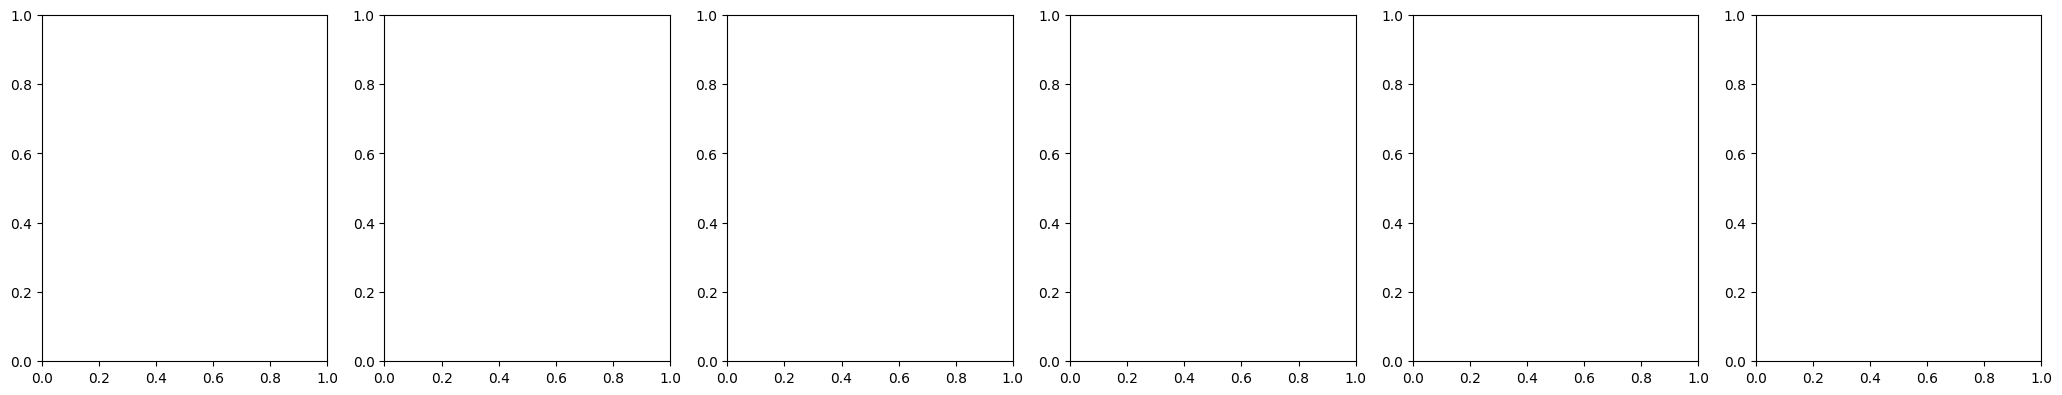

In [13]:
# 2.7 — Demo qualitativa: stessa immagine, stesso oggetto, tutte le mappe affiancate
def _first_demo():
    for rec in POOL_FULL[:200]:
        objs = sorted(c for c in rec["present"] if concept_id(c) is not None and c in rec["boxes"])
        if objs: return rec, objs[0]
    return None, None

demo_rec, demo_obj = _first_demo()
try:
    if demo_rec is not None:
        n = len(METHODS) + 1
        fig, ax = plt.subplots(1, n, figsize=(4.3 * n, 4.5))
        maps = {name: compute_saliency(kind, kw, demo_rec["image"], demo_obj)
                for name, (kind, kw) in METHODS.items()}
        ax[0].imshow(next(iter(maps.values()))[2])
        ax[0].set_title(f"'{demo_obj}' — immagine"); ax[0].axis("off")
        for k, (name, (sal, _, d)) in enumerate(maps.items(), start=1):
            ax[k].imshow(d); ax[k].imshow(np.kron(sal, np.ones((14, 14))), cmap="jet", alpha=0.5)
            ax[k].set_title(name); ax[k].axis("off")
        plt.tight_layout()
        plt.savefig(f"{RESULTS_DIR}/demo_maps.png", dpi=150, bbox_inches="tight")
        plt.show()

        # scomposizione TAM: grezza -> interferenza ECI -> causale -> +RGF
        sal, _, d, det = tam_saliency(demo_rec["image"], demo_obj, return_details=True)
        fig, ax = plt.subplots(1, 5, figsize=(21, 4.4))
        ax[0].imshow(d); ax[0].set_title("immagine")
        ax[1].imshow(det["raw"], cmap="jet"); ax[1].set_title("mappa grezza")
        ax[2].imshow(det["interference"], cmap="jet"); ax[2].set_title("interferenza ECI")
        ax[3].imshow(det["causal"], cmap="jet"); ax[3].set_title(f"dopo ECI (s={det['scale']:.3f})")
        ax[4].imshow(d); ax[4].imshow(np.kron(sal, np.ones((14, 14))), cmap="jet", alpha=0.5)
        ax[4].set_title("TAM + RGF")
        for a in ax: a.axis("off")
        fig.suptitle(f"TAM su '{demo_obj}' — token {det['token']!r} | prompt: {det['prompt']!r}")
        plt.tight_layout()
        plt.savefig(f"{RESULTS_DIR}/demo_tam_breakdown.png", dpi=150, bbox_inches="tight")
        plt.show()

        # scomposizione ERCR: ER multi-scala -> contesto pesato RBO -> residuo -> +rank-Gaussian
        sal, _, d, det = ercr_saliency(demo_rec["image"], demo_obj, return_details=True)
        fig, ax = plt.subplots(1, 5, figsize=(21, 4.4))
        ax[0].imshow(d); ax[0].set_title("immagine")
        ax[1].imshow(det["er"], cmap="jet"); ax[1].set_title(f"ER (scale {ER_SCALES})")
        ax[2].imshow(det["context"], cmap="jet")
        ax[2].set_title(f"contesto PCR ({det['n_context']} pos.)")
        ax[3].imshow(det["positive"], cmap="jet"); ax[3].set_title(f"residuo+ (beta={det['beta']:.3f})")
        ax[4].imshow(d); ax[4].imshow(np.kron(sal, np.ones((14, 14))), cmap="jet", alpha=0.5)
        ax[4].set_title("ERCR finale")
        for a in ax: a.axis("off")
        fig.suptitle(f"ERCR su '{demo_obj}' — RBO medio {det['rbo_mean']:.3f} | "
                     f"prompt: {det['prompt']!r} | risposta forzata: {det['answer']!r}")
        plt.tight_layout()
        plt.savefig(f"{RESULTS_DIR}/demo_ercr_breakdown.png", dpi=150, bbox_inches="tight")
        plt.show()
except Exception as e:
    print("demo saltata:", type(e).__name__, e)

# Parte 3 — Valutazione (protocollo invariato)

Occlusione, scoring, geometria, curve e metriche sono presi tali e quali dal tuo notebook. L'unica
modifica strutturale è nel loop: le mappe di tutti i metodi vengono calcolate **prima** di occludere
e, se un metodo fallisce, l'oggetto viene scartato per tutti — così il numero di campioni è
identico fra i metodi.

In [14]:
# 3.1 — Occlusione con patch nere + scoring  [identica all'originale]
PATCH = 14                                    # 24*14 = 336 (LLaVA-1.5, singola crop CLIP)
_BLACK = (-_mean / _std).to(DEVICE)           # nero (RGB 0) in spazio normalizzato

def _apply_patches(pv, flat_idx, gw, keep=False):
    """Se keep=False -> annerisce i patch in flat_idx. Se keep=True -> annerisce TUTTO tranne quelli."""
    pv = pv.clone()
    black = _BLACK.view(1, 3, 1, 1).to(pv.dtype)
    if keep:
        mask = torch.ones(gw * gw, dtype=torch.bool)
        mask[list(flat_idx)] = False
        target = torch.where(mask)[0].tolist()
    else:
        target = list(flat_idx)
    for idx in target:
        r, c = divmod(int(idx), gw)
        pv[..., r*PATCH:(r+1)*PATCH, c*PATCH:(c+1)*PATCH] = black
    return pv

SCORE_MODE   = "prob" if QUICK_TEST else "generate"   # "prob" = 1 forward/step | "generate" = fedele
MAX_NEW_EVAL = 24

def saliency_order(sal, gw, seed=0):
    """Indici di patch (flat) in ordine di salienza decrescente.

    I pareggi vengono rotti a caso (con seed deterministico) e NON per indice. Serve all'equita':
    TAM ed ERCR clippano a zero (ReLU), quindi centinaia di patch restano esattamente a pari merito,
    mentre jac/logit sono softmax e non pareggiano quasi mai. Con np.argsort puro i pareggi
    finirebbero ordinati per posizione, cioe' in scansione riga-per-riga: oltre una certa frazione
    di occlusione l'ordine non sarebbe piu' guidato dalla salienza ma dalla geometria della griglia,
    penalizzando o favorendo sistematicamente i metodi che producono zeri."""
    flat = np.asarray(sal, dtype=float).reshape(-1)
    jitter = np.random.default_rng(seed).random(flat.shape)
    return list(np.lexsort((jitter, flat))[::-1])

def tie_stats(sal):
    """(frazione di patch al valore minimo, numero di valori distinti): diagnostica dei pareggi."""
    flat = np.asarray(sal, dtype=float).reshape(-1)
    return float((flat == flat.min()).mean()), int(len(np.unique(flat)))

@torch.no_grad()
def object_scores_batch(base_meta, pv_stack, obj, chunk=18):
    """pv_stack: (B,3,336,336) varianti occluse della STESSA immagine/prompt.
    -> np.array (B,) con il segnale 'il VLM nomina l'oggetto' per ciascuna variante."""
    cid = concept_id(obj)
    ids = base_meta["inputs"]["input_ids"]
    am  = base_meta["inputs"]["attention_mask"]
    scores = []
    for s in range(0, pv_stack.shape[0], chunk):
        pv = pv_stack[s:s+chunk]; b = pv.shape[0]
        if SCORE_MODE == "prob":
            out = model(input_ids=ids.expand(b, -1), attention_mask=am.expand(b, -1),
                        pixel_values=pv, use_cache=False)
            p = out.logits[:, -1].float().softmax(-1)[:, cid]      # P(primo token == obj)
            scores.append(p.cpu().numpy())
        else:  # "generate": batch di didascalie (prompt identici -> nessun padding)
            gen = model.generate(input_ids=ids.expand(b, -1), attention_mask=am.expand(b, -1),
                                 pixel_values=pv, max_new_tokens=MAX_NEW_EVAL, do_sample=False)
            txts = tok.batch_decode(gen[:, ids.shape[1]:], skip_special_tokens=True)
            scores.append(np.array([float(mentions(t, obj)) for t in txts]))
    return np.concatenate(scores)

print("scoring:", SCORE_MODE)

scoring: generate


In [15]:
# 3.2 — Geometria: bbox originale -> canvas 336  [identica all'originale]
def orig_bbox_to_canvas(bbox, W, H, crop=336):
    x, y, w, h = bbox
    scale = crop / min(W, H)
    left = (W*scale - crop)/2.0; top = (H*scale - crop)/2.0
    x0 = x*scale - left; y0 = y*scale - top
    x1 = (x+w)*scale - left; y1 = (y+h)*scale - top
    x0, x1 = max(0.0, x0), min(float(crop), x1)
    y0, y1 = max(0.0, y0), min(float(crop), y1)
    if x1 <= x0 or y1 <= y0: return None       # box fuori dalla crop
    return (x0, y0, x1, y1)

def pointing_hit(sal, gw, boxes, W, H, seed=0):
    """True se il patch a salienza massima cade in una qualsiasi bbox GT (proiettata sul canvas).
    Anche qui i pareggi sul massimo vanno rotti a caso: np.argmax restituirebbe il primo indice,
    cioe' il patch piu' in alto a sinistra, favorendo le mappe con molti massimi identici."""
    canvas_boxes = [b for b in (orig_bbox_to_canvas(bb, W, H) for bb in boxes) if b is not None]
    if not canvas_boxes: return None
    p = saliency_order(sal, gw, seed=seed)[0]; r, c = divmod(p, gw)
    cy = (r + 0.5) * PATCH; cx = (c + 0.5) * PATCH
    return any(x0 <= cx <= x1 and y0 <= cy <= y1 for (x0, y0, x1, y1) in canvas_boxes)


# --- maschera ground-truth sulla griglia 24x24: serve a ROC AUC e AP ---
MASK_RULE = "center"     # "center" = patch positivo se il suo CENTRO cade nella bbox (coerente con
                         #            il pointing game)
                         # "overlap" = patch positivo se si sovrappone anche solo in parte alla bbox
                         #            (piu' generoso: salva gli oggetti piccoli, che con "center"
                         #             possono dare maschere vuote e quindi metriche indefinite)

def gt_mask(boxes, W, H, gh, gw, rule=None):
    """-> maschera gh x gw {0,1} con i patch che coprono l'oggetto, o None se la box e' fuori crop."""
    rule = MASK_RULE if rule is None else rule
    canvas_boxes = [b for b in (orig_bbox_to_canvas(bb, W, H) for bb in boxes) if b is not None]
    if not canvas_boxes: return None
    m = np.zeros((gh, gw), dtype=np.float32)
    for r in range(gh):
        py0, py1 = r * PATCH, (r + 1) * PATCH
        cy = (py0 + py1) / 2.0
        for c in range(gw):
            px0, px1 = c * PATCH, (c + 1) * PATCH
            cx = (px0 + px1) / 2.0
            if rule == "center":
                ok = any(x0 <= cx <= x1 and y0 <= cy <= y1 for (x0, y0, x1, y1) in canvas_boxes)
            else:  # overlap
                ok = any(px0 < x1 and px1 > x0 and py0 < y1 and py1 > y0
                         for (x0, y0, x1, y1) in canvas_boxes)
            if ok: m[r, c] = 1.0
    return m


# --- ROC AUC e Average Precision, implementati a mano (identici a sklearn, verificati) ---
# Nota: a differenza di deletion/insertion, queste due metriche NON dipendono da un ordinamento
# arbitrario dei pareggi. La ROC usa i ranghi medi sui valori uguali e l'AP raggruppa i pareggi in
# un unico punto della curva precision-recall. Sono quindi piu' robuste per TAM ed ERCR, che dopo
# la ReLU producono centinaia di patch esattamente a zero.

def _avg_ranks(s):
    order = np.argsort(s, kind="mergesort"); s_sorted = s[order]
    ranks = np.empty(len(s), dtype=float); i = 0; n = len(s)
    while i < n:
        j = i
        while j + 1 < n and s_sorted[j + 1] == s_sorted[i]: j += 1
        ranks[order[i:j+1]] = 0.5 * (i + j) + 1.0     # rango medio sui pareggi
        i = j + 1
    return ranks

def roc_auc_score_np(scores, labels):
    """AUC della ROC via Mann-Whitney U con correzione dei pareggi. None se una classe e' assente."""
    y = np.asarray(labels).reshape(-1).astype(bool)
    s = np.asarray(scores, dtype=float).reshape(-1)
    n_pos, n_neg = int(y.sum()), int((~y).sum())
    if n_pos == 0 or n_neg == 0: return None          # metrica indefinita
    r = _avg_ranks(s)
    return float((r[y].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))

def average_precision_np(scores, labels):
    """AP = somma di (delta recall) * precision, con i pareggi raggruppati. None se non ci sono positivi."""
    y = np.asarray(labels).reshape(-1).astype(float)
    s = np.asarray(scores, dtype=float).reshape(-1)
    n_pos = y.sum()
    if n_pos == 0: return None
    order = np.argsort(-s, kind="mergesort")
    y_s, s_s = y[order], s[order]
    tp, fp = np.cumsum(y_s), np.cumsum(1.0 - y_s)
    keep = np.r_[np.diff(s_s) != 0, True]             # un solo punto per gruppo di pareggi
    tp, fp = tp[keep], fp[keep]
    prec, rec = tp / (tp + fp), tp / n_pos
    return float(np.sum(np.diff(np.r_[0.0, rec]) * prec))

print("metriche di localizzazione ok | regola maschera:", MASK_RULE)

metriche di localizzazione ok | regola maschera: center


In [16]:
# 3.3 — FAITHFULNESS VIOLATION TEST  (Liu et al., ICML 2022, arXiv:2201.12114)
#
#   x*   = insieme delle patch col peso di spiegazione piu' alto
#   dC   = f(x)_y - f(x \ x*)_y       perturbazione di confidenza dopo averle rimosse
#   Violation = 1[ sign( w(x*) * dC ) < 0 ]
# Cioe': una violazione e' quando le patch indicate come piu' importanti, se rimosse, fanno SALIRE
# la confidenza -- stanno sopprimendo la predizione invece di sostenerla. Si riporta la frazione di
# violazioni (piu' bassa = meglio).
#
# GRANULARITA'. La definizione formale in Sezione 3 del paper prende UNA feature. Per le regioni
# visive, pero', gli autori stessi istanziano il test sul TOP-10% (Figura 1: "after removing top-10%
# image regions w.r.t attention weights"). Su una griglia 24x24 una singola patch e' 1/576
# dell'immagine e il segnale sarebbe dominato dal rumore, quindi qui usiamo il top-10% -- cioe' 58
# patch -- coerentemente con l'istanziazione visiva del paper. w(x*) e' il peso medio dell'insieme.
FVT_FRAC = 0.10
#
# OTTIMIZZAZIONE. La confidenza originale e' la stessa per tutti i metodi, e insiemi identici fra
# metodi vengono deduplicati: per ogni coppia (immagine, oggetto) basta un solo batch con
# [immagine intatta] + [una variante per ciascun insieme top-10% DISTINTO]. Nessuna generate.
#
# CONFIDENZA. Il paper usa f(x)_y, la probabilita' della classe predetta. Qui la "predizione" da
# spiegare e' "il modello riconosce l'oggetto", quindi leggo P(token oggetto) subito dopo un prefisso
# di risposta forzato: molto piu' sensibile della probabilita' del PRIMO token della risposta, che
# sotto DESCRIBE_Q sarebbe quasi sempre "The" e renderebbe dC quasi ovunque nullo.
FVT_ANSWER_PREFIX = " The image contains a"
FVT_CHUNK = 16

@torch.no_grad()
def fvt_confidence(image, obj, pv_stack, chunk=FVT_CHUNK):
    """-> np.array (B,) con P(token di obj) per ciascuna variante di pixel_values."""
    cid = concept_id(obj)
    meta = build_inputs(image, DESCRIBE_Q)
    ids = meta["inputs"]["input_ids"]
    pre = torch.tensor([tok.encode(FVT_ANSWER_PREFIX, add_special_tokens=False)],
                       device=ids.device, dtype=ids.dtype)
    full = torch.cat([ids, pre], dim=1)
    am   = torch.cat([meta["inputs"]["attention_mask"], torch.ones_like(pre)], dim=1)
    out = []
    for s in range(0, pv_stack.shape[0], chunk):
        pv = pv_stack[s:s+chunk]; b = pv.shape[0]
        o = model(input_ids=full.expand(b, -1), attention_mask=am.expand(b, -1),
                  pixel_values=pv, use_cache=False)
        out.append(o.logits[:, -1].float().softmax(-1)[:, cid].cpu().numpy())
    return np.concatenate(out)

@torch.no_grad()
def faithfulness_violation(image, obj, sals, seed=0):
    """sals: {nome: (mappa, gh, gw)} -> {nome: (violation 0/1, dC, peso di x*)}.
    Una sola forward batch per coppia, condivisa fra tutti i metodi."""
    tops, wtop = {}, {}
    for name, (sal, gh, gw) in sals.items():
        flat = np.asarray(sal, dtype=float).reshape(-1)
        k = max(1, int(round(FVT_FRAC * gh * gw)))
        # ordinamento per valore ASSOLUTO, cosi' la definizione vale anche per le mappe segnate
        order = saliency_order(np.abs(flat).reshape(sal.shape), gw, seed=seed)
        sel = tuple(sorted(order[:k]))
        tops[name] = sel
        wtop[name] = float(np.mean(flat[list(sel)]))     # w(x*) = peso medio dell'insieme
    uniq = sorted(set(tops.values()))

    base_meta = build_inputs(image, DESCRIBE_Q)
    pv0 = base_meta["inputs"]["pixel_values"]
    gw0 = next(iter(sals.values()))[2]
    stack = torch.cat([pv0] + [_apply_patches(pv0, list(t), gw0, keep=False) for t in uniq], dim=0)
    conf = fvt_confidence(image, obj, stack)
    c0 = float(conf[0])
    cmap = {t: float(c) for t, c in zip(uniq, conf[1:])}

    out = {}
    for name in sals:
        dC = c0 - cmap[tops[name]]                       # >0 = la rimozione abbassa la confidenza
        out[name] = (int(np.sign(wtop[name] * dC) < 0), dC, wtop[name])
    return out

print(f"faithfulness violation test pronto | rimozione top-{FVT_FRAC:.0%} "
      f"({int(round(FVT_FRAC*576))} patch su 576) | confidenza dopo {FVT_ANSWER_PREFIX!r}")

faithfulness violation test pronto | rimozione top-10% (58 patch su 576) | confidenza dopo ' The image contains a'


In [17]:
# 3.4 — Curve di deletion e insertion  [logica identica; prende la mappa gia' calcolata]
OCC_STEPS = 10                      # numero di frazioni (0..1)
FRACS = np.linspace(0, 1, OCC_STEPS + 1)

@torch.no_grad()
def del_ins_curves_from_sal(image, obj, sal, gh, gw, chunk=18, seed=0):
    order = saliency_order(sal, gw, seed=seed)
    base_meta = build_inputs(image, DESCRIBE_Q)          # scoring sempre con lo stesso prompt
    pv0 = base_meta["inputs"]["pixel_values"]            # (1,3,336,336)
    n = gh * gw

    del_pvs, ins_pvs = [], []
    for f in FRACS:
        k = int(round(f * n))
        del_pvs.append(pv0 if k == 0 else _apply_patches(pv0, order[:k], gw, keep=False))
        ins_pvs.append(_apply_patches(pv0, order[:k], gw, keep=True))   # k=0 -> tutto nero

    stack = torch.cat(del_pvs + ins_pvs, dim=0)          # (2*(OCC_STEPS+1), 3, 336, 336)
    sc = object_scores_batch(base_meta, stack, obj, chunk=chunk)
    m = len(FRACS)

    return sc[:m], sc[m:]                                # deletion, insertion

def auc(y):                                    # trapezio su [0,1] -> AUC in [0,1]
    y = np.asarray(y, dtype=float)
    return float(np.sum((y[:-1] + y[1:]) / 2.0 * np.diff(FRACS)))

In [18]:
# 3.5 — Parametri di valutazione + stima del costo (cella veloce, non usa il modello)
N_EVAL          = 20 if QUICK_TEST else 500

# Oggetti per immagine. 3 = come il tuo run originale. None = TUTTI gli oggetti eleggibili:
# in quel caso l'insieme delle coppie non dipende piu' dall'ordine di iterazione del set, perche'
# sparisce il troncamento (che era l'unico punto in cui l'ordine contava). Media e curve medie sono
# invarianti all'ordine, quindi con None due run diversi danno gli STESSI identici numeri.
MAX_OBJ_PER_IMG = None

_ST = set(SINGLE_TOKEN_CATS)
_counts = []
for rec in POOL_FULL[:max(N_EVAL*3, N_EVAL)]:
    k = sum(1 for c in rec["present"] if c in _ST and c in rec["boxes"])
    if k: _counts.append(k)
    if len(_counts) >= N_EVAL: break
_counts = np.asarray(_counts)

print(f"immagini con almeno un oggetto valutabile: {len(_counts)}")
print(f"oggetti eleggibili per immagine: media {_counts.mean():.2f}, "
      f"mediana {np.median(_counts):.0f}, max {_counts.max()}")
print(f"immagini con piu' di 3 oggetti (le uniche in cui il cap cambia qualcosa): "
      f"{int((_counts > 3).sum())} ({(_counts > 3).mean():.1%})\n")
for cap in (1, 2, 3, None):
    tot = int(_counts.sum()) if cap is None else int(np.minimum(_counts, cap).sum())
    gen = tot * len(METHODS) * 2 * (10 + 1)      # generate del run principale (OCC_STEPS=10)
    print(f"  MAX_OBJ_PER_IMG={str(cap):<5} -> {tot:>6} coppie | {gen:>7} generate "
          f"({'scelto' if cap == MAX_OBJ_PER_IMG else ''})")

immagini con almeno un oggetto valutabile: 500
oggetti eleggibili per immagine: media 1.89, mediana 2, max 8
immagini con piu' di 3 oggetti (le uniche in cui il cap cambia qualcosa): 51 (10.2%)

  MAX_OBJ_PER_IMG=1     ->    500 coppie |   55000 generate ()
  MAX_OBJ_PER_IMG=2     ->    752 coppie |   82720 generate ()
  MAX_OBJ_PER_IMG=3     ->    859 coppie |   94490 generate ()
  MAX_OBJ_PER_IMG=None  ->    943 coppie |  103730 generate (scelto)


In [19]:
# 3.6 — Motore di valutazione (riusabile: stesso codice per il run principale e per i controlli)
def run_eval(methods, n_eval, tag, do_fidelity=True, do_fvt=True, force_pairs=None):
    """-> (results, pairs, prevalence, skipped). Tutti i metodi vengono valutati sulle STESSE
    coppie: se anche uno solo fallisce la mappa, l'oggetto viene scartato per tutti."""
    res = {n: dict(point=[], del_auc=[], ins_auc=[], del_curve=[], ins_curve=[],
                   roc=[], ap=[], tie_frac=[], fvt_viol=[], fvt_dC=[], fvt_w=[]) for n in methods}
    prev, out_pairs, skip = [], [], []

    fp = None
    if force_pairs is not None:
        fp = {}
        for i_img, obj in force_pairs: fp.setdefault(int(i_img), []).append(obj)

    evaluated = 0
    for i_img, rec in enumerate(POOL_FULL[:max(n_eval*3, n_eval)]):
        if evaluated >= n_eval: break
        img, present, boxes, (W, H) = rec["image"], rec["present"], rec["boxes"], rec["size"]

        if fp is not None:
            objs = [o for o in fp.get(i_img, []) if o in boxes]
        else:
            # sorted(): `present` e' un set e l'ordine di iterazione dipende dall'hash randomizzato
            # per processo. Con MAX_OBJ_PER_IMG=None il troncamento sparisce e l'insieme delle
            # coppie non dipende piu' dall'ordine; sorted lo rende deterministico anche col cap.
            objs = sorted(c for c in present if concept_id(c) is not None and c in boxes)
            if MAX_OBJ_PER_IMG is not None: objs = objs[:MAX_OBJ_PER_IMG]
        if not objs: continue
        used = False

        for obj in objs:
            # 1) tutte le mappe prima di occludere; cache condivisa fra spec con la stessa base
            sals, cache = {}, {}
            try:
                for name, spec in methods.items():
                    sal, (gh, gw), _ = saliency_for(spec, img, obj, cache=cache)
                    sals[name] = (sal, gh, gw)
            except Exception as e:
                skip.append((i_img, obj, f"{type(e).__name__}: {e}"))
                continue

            # 2) stesso seed di tie-break per tutti i metodi sulla stessa coppia.
            #    crc32 e non hash(): hash() sulle stringhe e' randomizzato per processo.
            pair_seed = zlib.crc32(f"{i_img}|{obj}".encode()) % (2**31)
            gh0, gw0 = next(iter(sals.values()))[1:]
            mask = gt_mask(boxes[obj], W, H, gh0, gw0)
            if mask is not None: prev.append(float(mask.mean()))

            # faithfulness violation test: un solo batch condiviso da tutti i metodi
            if do_fvt:
                try:
                    fv = faithfulness_violation(img, obj, sals, seed=pair_seed)
                    for name, (v, dC, w) in fv.items():
                        res[name]["fvt_viol"].append(v); res[name]["fvt_dC"].append(dC)
                        res[name]["fvt_w"].append(w)
                except Exception as e:
                    skip.append((i_img, obj, f"[FVT] {type(e).__name__}: {e}"))

            for name, (sal, gh, gw) in sals.items():
                # --- localizzazione PRIMA della fedelta': dipende solo dalla mappa e dalla
                #     maschera, quindi tutti i metodi appendono sempre, sulla stessa coppia.
                #     Se la calcolassi dopo, un fallimento dell'occlusione farebbe saltare (via
                #     `continue`) anche roc/ap solo per quel metodo, disallineando gli array e
                #     invalidando qualunque confronto appaiato.
                hit = pointing_hit(sal, gw, boxes[obj], W, H, seed=pair_seed)
                if hit is not None: res[name]["point"].append(int(hit))
                if mask is not None:
                    ra = roc_auc_score_np(sal, mask); ap = average_precision_np(sal, mask)
                    if ra is not None: res[name]["roc"].append(ra)
                    if ap is not None: res[name]["ap"].append(ap)
                res[name]["tie_frac"].append(tie_stats(sal)[0])
                used = True

                if do_fidelity:
                    try:
                        dcur, icur = del_ins_curves_from_sal(img, obj, sal, gh, gw, seed=pair_seed)
                    except Exception as e:
                        skip.append((i_img, obj, f"[{name}] {type(e).__name__}: {e}"))
                        continue
                    res[name]["del_auc"].append(auc(dcur))
                    res[name]["ins_auc"].append(auc(icur))
                    res[name]["del_curve"].append(dcur)
                    res[name]["ins_curve"].append(icur)
            out_pairs.append((i_img, obj))

        evaluated += int(used)
        print(f"[{tag}] immagini: {evaluated}/{n_eval} | coppie: {len(out_pairs)} | "
              f"scartate: {len(skip)}", end="\r")
        torch.save(res, f"{RESULTS_DIR}/task2_partial_{tag}.pt")

    torch.save(res, f"{RESULTS_DIR}/task2_partial_{tag}.pt")
    print()
    return res, out_pairs, prev, skip


def summarize(res, methods, prev, title, csv_path=None, show_fidelity=True):
    PREV = float(np.mean(prev)) if prev else float("nan")
    _m = lambda v: (np.mean(v) if len(v) else float("nan"))
    print(f"\n=== {title} ===")
    head = f"{'metodo':<24} | {'n':>5} | {'pointing':>8} | {'ROC AUC':>7} | {'AP':>6} | {'viol.':>6}"
    if show_fidelity: head += f" | {'del AUC':>7} | {'ins AUC':>7} | {'pari':>5}"
    print(head); print("-"*len(head))
    rows = []
    for name in methods:
        r = res[name]
        n = len(r["del_auc"]) if show_fidelity and r["del_auc"] else len(r["point"])
        line = (f"{name:<24} | {n:>5} | {_m(r['point']):7.1%} | {_m(r['roc']):7.3f} | "
                f"{_m(r['ap']):6.3f} | {_m(r['fvt_viol']):5.1%}")
        if show_fidelity:
            line += f" | {_m(r['del_auc']):7.3f} | {_m(r['ins_auc']):7.3f} | {_m(r['tie_frac']):4.0%}"
        print(line)
        rows.append(dict(metodo=name, n=n, pointing=_m(r["point"]), roc_auc=_m(r["roc"]),
                         ap=_m(r["ap"]), violation_ratio=_m(r["fvt_viol"]),
                         delta_C_medio=_m(r["fvt_dC"]), deletion_auc=_m(r["del_auc"]),
                         insertion_auc=_m(r["ins_auc"]), tie_frac=_m(r["tie_frac"]),
                         ap_baseline=PREV, n_roc=len(r["roc"]), n_ap=len(r["ap"]),
                         n_fvt=len(r["fvt_viol"])))
    print(f"\nROC casuale = 0.500 | AP casuale ~ {PREV:.3f} (prevalenza) | pointing casuale ~ {PREV:.1%}")
    print("viol. = faithfulness violation ratio (piu' bassa = meglio): frazione di coppie in cui")
    print("        rimuovere la patch piu' saliente FA SALIRE la confidenza sull'oggetto.")
    if csv_path:
        pd.DataFrame(rows).to_csv(csv_path, index=False); print("salvato:", csv_path)
    return pd.DataFrame(rows), PREV

In [ ]:
# 3.7 — RUN PRINCIPALE: i 4 metodi nella loro configurazione nativa, protocollo completo
results, pairs, prevalence, skipped = run_eval(METHODS, N_EVAL, tag="main", do_fidelity=True)

torch.save(pairs, f"{RESULTS_DIR}/task2_pairs.pt")
torch.save(dict(results=results, pairs=pairs, skipped=skipped, prevalence=prevalence,
                methods=list(METHODS),
                config=dict(N_EVAL=N_EVAL, MAX_OBJ_PER_IMG=MAX_OBJ_PER_IMG, OCC_STEPS=OCC_STEPS,
                            SCORE_MODE=SCORE_MODE, MAX_NEW_EVAL=MAX_NEW_EVAL, FIRST_K=FIRST_K,
                            MASK_RULE=MASK_RULE, TAM_LAYER=TAM_LAYER,
                            TAM_PROMPT=TAM_PROMPT_TEMPLATE, ER_SCALES=ER_SCALES,
                            ERCR_LAYER=ERCR_LAYER, ERCR_TOPK=ERCR_TOPK, ERCR_RBO_P=ERCR_RBO_P,
                            ERCR_ANSWER=ERCR_ANSWER_TEMPLATE)),
           f"{RESULTS_DIR}/task2_final.pt")

df_main, PREV = summarize(results, METHODS, prevalence, "RUN PRINCIPALE (config native)",
                          csv_path=f"{RESULTS_DIR}/task2_summary.csv")
print(f"\ncoppie: {len(pairs)} | scartate: {len(skipped)} | maschere GT valide: {len(prevalence)}")
if skipped[:5]: print("primi scarti:", skipped[:5])

In [ ]:
# 3.8 — RUN DI CONTROLLO: stesse identiche coppie, solo metriche di localizzazione.
#   Niente occlusione -> nessuna generate, costa una frazione del run principale.
#   Serve a rispondere a: la differenza e' del METODO o del contorno (filtro, prompt, layer)?
RUN_CONTROLS = True

if RUN_CONTROLS:
    res_c, pairs_c, prev_c, skip_c = run_eval(CONTROLS, N_EVAL, tag="ctrl",
                                              do_fidelity=False, force_pairs=pairs)
    torch.save(dict(results=res_c, pairs=pairs_c, prevalence=prev_c, skipped=skip_c),
               f"{RESULTS_DIR}/task2_controls.pt")
    df_ctrl, _ = summarize(res_c, CONTROLS, prev_c, "CONTROLLI (localizzazione, stesse coppie)",
                           csv_path=f"{RESULTS_DIR}/task2_controls.csv", show_fidelity=False)
    print(f"\ncoppie di controllo: {len(pairs_c)} (devono coincidere con le {len(pairs)} principali)")

    def _d(a, b, key):
        va, vb = res_c[a][key], res_c[b][key]
        return (np.mean(vb) - np.mean(va)) if (len(va) and len(vb)) else float("nan")

    print("\n--- Quanto vale ogni singolo ingrediente (delta su jac) ---")
    for etichetta, a, b in [
            ("solo filtro RGF          ", "jac (J^V)", "jac + RGF"),
            ("vecchio prompt emozioni  ", "jac (J^V)", "jac @ PROMPT_Q"),
            ("prompt neutro DESCRIBE_Q ", "jac (J^V)", "jac @ DESCRIBE_Q"),
            ("solo ensemble multi-scala", "jac (J^V)", "jac multi-scala (ER)"),
            ("TAM: quanto pesa il RGF", "TAM senza RGF", "TAM (ECI+RGF)"),
            ("ERCR: quanto pesa il filtro", "ERCR senza filtro", "ERCR"),
            ("ERCR: auto-sottrazione indotta dal prompt", "ERCR", "ERCR senza auto-sottraz.")]:
        print(f"  {etichetta}: pointing {_d(a,b,'point'):+.1%} | "
              f"ROC {_d(a,b,'roc'):+.3f} | AP {_d(a,b,'ap'):+.3f}")
    print("\nConfronto da fare: se il divario TAM - jac e' dello stesso ordine di 'filtro + prompt',")
    print("quel divario NON e' attribuibile al metodo. Il confronto pulito e' fra righe che")
    print("condividono filtro e prompt (es. 'jac + RGF @ prompt TAM' contro 'TAM (ECI+RGF)').")

In [ ]:
# 3.9 — Riferimento esterno (facoltativo): un tuo run precedente, se vuoi sovrapporlo.
#   Ora non serve piu': jac e logit girano dentro questo notebook, sulle stesse coppie.
ref = {}
if OVERLAY_REF and os.path.exists(REF_RESULTS_PATH):
    try:
        blob_ref = torch_load_any(REF_RESULTS_PATH)
        for name, r in blob_ref.items():
            if not isinstance(r, dict) or "del_curve" not in r: continue
            if r["del_curve"] and len(np.asarray(r["del_curve"][0])) != len(FRACS): continue
            ref[f"{name} *"] = r
        print("riferimento esterno:", list(ref))
    except Exception as e:
        print("riferimento non caricato:", type(e).__name__, e)


# 3.10 — Grafici del run principale
allr = {**{n: results[n] for n in METHODS}, **ref}
names = list(allr)
palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860", "#DA8BC3"]
colors = {n: palette[i % len(palette)] for i, n in enumerate(names)}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for n in names:
    r, dashed = allr[n], n.endswith(" *")
    st = dict(linestyle="--" if dashed else "-", alpha=0.6 if dashed else 1.0, color=colors[n])
    if r["del_curve"]: ax[0].plot(FRACS, np.mean(r["del_curve"], 0), marker="o", label=n, **st)
    if r["ins_curve"]: ax[1].plot(FRACS, np.mean(r["ins_curve"], 0), marker="o", label=n, **st)
ax[0].set_title("Deletion (piu' bassa = meglio)"); ax[0].set_xlabel("frazione patch oscurati")
ax[0].set_ylabel("segnale oggetto"); ax[0].legend(fontsize=8)
ax[1].set_title("Insertion (piu' alta = meglio)"); ax[1].set_xlabel("frazione patch rivelati")
ax[1].set_ylabel("segnale oggetto"); ax[1].legend(fontsize=8)

xpos = np.arange(len(names)); wbar = 0.35
da = [np.mean(allr[n]["del_auc"]) if allr[n]["del_auc"] else 0 for n in names]
ia = [np.mean(allr[n]["ins_auc"]) if allr[n]["ins_auc"] else 0 for n in names]
ax[2].bar(xpos - wbar/2, da, wbar, label="deletion AUC", color="#C44E52")
ax[2].bar(xpos + wbar/2, ia, wbar, label="insertion AUC", color="#8172B3")
ax[2].set_xticks(xpos); ax[2].set_xticklabels(names, rotation=15, ha="right"); ax[2].set_ylim(0, 1)
ax[2].set_title("Fedeltà"); ax[2].legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task2_curves.png", dpi=150, bbox_inches="tight")
plt.show()


# 3.11 — Metriche di localizzazione del run principale
def localization_panels(res, order, prev_val, fname, suptitle):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
    for k, (key, title, chance) in enumerate([("point", "Pointing game", prev_val),
                                              ("roc", "ROC AUC", 0.5),
                                              ("ap", "Average Precision", prev_val)]):
        vals, errs = [], []
        for n in order:
            v = res[n].get(key, [])
            vals.append(float(np.mean(v)) if len(v) else np.nan)
            errs.append(float(np.std(v, ddof=1)/math.sqrt(len(v))) if len(v) > 1 else 0.0)
        ax[k].bar(np.arange(len(order)), vals, 0.6, yerr=errs, capsize=4,
                  color=[colors.get(n, "#7f7f7f") for n in order])
        if np.isfinite(chance):
            ax[k].axhline(chance, ls=":", c="k", lw=1.2, label=f"caso = {chance:.3f}")
            ax[k].legend(fontsize=8)
        for x, v in enumerate(vals):
            if np.isfinite(v): ax[k].text(x, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        ax[k].set_xticks(np.arange(len(order)))
        ax[k].set_xticklabels(order, rotation=20, ha="right", fontsize=8)
        ax[k].set_ylim(0, 1); ax[k].set_title(title)
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

localization_panels(allr, names, PREV, f"{RESULTS_DIR}/task2_localization.png",
                    "Localizzazione — run principale (barre = errore standard)")

# 3.12 — Controlli: stessa figura, con le varianti a confondente isolato
if RUN_CONTROLS:
    ctrl_names = list(CONTROLS)
    colors.update({n: ("#4C72B0" if n.startswith("jac") or n.startswith("logit")
                       else "#DD8452" if n.startswith("TAM") else "#55A868")
                   for n in ctrl_names})
    localization_panels(res_c, ctrl_names, float(np.mean(prev_c)) if prev_c else np.nan,
                        f"{RESULTS_DIR}/task2_controls.png",
                        "Controlli — stesse coppie, un ingrediente alla volta")

In [ ]:
# 3.13 — CONFRONTO APPAIATO su ROC AUC e AP
#
# Tutti i metodi vedono le stesse coppie nello stesso ordine, quindi i vettori per-coppia sono
# allineati e si puo' fare un confronto APPAIATO: molto piu' potente del confronto fra medie, perche'
# elimina la varianza dovuta alla difficolta' dell'immagine (un oggetto piccolo e' difficile per
# tutti). La differenza media appaiata puo' essere significativa anche quando gli intervalli di
# confidenza delle due medie si sovrappongono.
try:
    from scipy.stats import wilcoxon
    _HAS_WILCOXON = True
except Exception:
    _HAS_WILCOXON = False

BASELINE = "jac (J^V)"          # metodo di riferimento del confronto

def paired_table(res, methods, keys=("roc", "ap", "point"), baseline=BASELINE, n_boot=2000):
    """Differenza appaiata di ogni metodo rispetto al baseline, con IC bootstrap e p-value."""
    rows = []
    rng = np.random.default_rng(0)
    for key in keys:
        base = np.asarray(res[baseline][key], dtype=float)
        for name in methods:
            if name == baseline: continue
            other = np.asarray(res[name][key], dtype=float)
            if len(base) != len(other) or len(base) == 0:
                rows.append(dict(metrica=key, metodo=name, n=min(len(base), len(other)),
                                 delta=np.nan, ic_basso=np.nan, ic_alto=np.nan,
                                 win_rate=np.nan, p=np.nan,
                                 nota="vettori non allineati: confronto appaiato non valido"))
                continue
            d = other - base
            idx = rng.integers(0, len(d), size=(n_boot, len(d)))
            boot = d[idx].mean(axis=1)
            lo, hi = np.percentile(boot, [2.5, 97.5])
            nz = d[d != 0]
            if _HAS_WILCOXON and len(nz) > 0:
                try: p = float(wilcoxon(other, base, zero_method="wilcox").pvalue)
                except Exception: p = np.nan
            else:
                p = np.nan
            rows.append(dict(metrica=key, metodo=name, n=len(d), delta=float(d.mean()),
                             ic_basso=float(lo), ic_alto=float(hi),
                             win_rate=float((d > 0).mean()), p=p,
                             nota="IC 95% bootstrap sulla differenza appaiata"))
    return pd.DataFrame(rows)

# controllo di allineamento: e' la precondizione del confronto appaiato
lens = {n: (len(results[n]["roc"]), len(results[n]["ap"]), len(results[n]["point"]))
        for n in METHODS}
print("lunghezze (roc, ap, point) per metodo:", lens)
allineati = len(set(lens.values())) == 1
print("vettori allineati fra metodi:", allineati,
      "" if allineati else "  <-- confronto appaiato NON valido, controlla `skipped`")

df_paired = paired_table(results, METHODS)
df_paired.to_csv(f"{RESULTS_DIR}/task2_paired_vs_{BASELINE.split()[0]}.csv", index=False)

print(f"\n=== DIFFERENZA APPAIATA rispetto a '{BASELINE}' ===")
print(f"{'metrica':<8} | {'metodo':<16} | {'delta':>8} | {'IC 95%':>18} | {'win rate':>8} | {'p':>9}")
print("-"*82)
for _, r in df_paired.iterrows():
    p = "n/d" if not np.isfinite(r["p"]) else (f"{r['p']:.2e}" if r["p"] < 1e-3 else f"{r['p']:.4f}")
    ic = f"[{r['ic_basso']:+.3f}, {r['ic_alto']:+.3f}]"
    print(f"{r['metrica']:<8} | {r['metodo']:<16} | {r['delta']:+8.4f} | {ic:>18} | "
          f"{r['win_rate']:7.1%} | {p:>9}")
print("\ndelta > 0 = il metodo batte il baseline | IC che NON contiene 0 = differenza solida")
print("win rate = frazione di coppie in cui il metodo supera il baseline")
if not _HAS_WILCOXON:
    print("scipy non disponibile: p-value omessi (delta, IC e win rate restano validi)")

# distribuzioni per-coppia: la media da sola nasconde le code
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for k, key in enumerate(["roc", "ap"]):
    data = [np.asarray(results[n][key], dtype=float) for n in METHODS]
    bp = ax[k].boxplot(data, labels=list(METHODS), showmeans=True, patch_artist=True)
    for patch, n in zip(bp["boxes"], METHODS):
        patch.set_facecolor(colors.get(n, "#999999")); patch.set_alpha(0.55)
    if key == "roc": ax[k].axhline(0.5, ls=":", c="k", lw=1.2, label="caso = 0.5")
    else:            ax[k].axhline(PREV, ls=":", c="k", lw=1.2, label=f"caso = {PREV:.3f}")
    ax[k].legend(fontsize=8)
    ax[k].set_title(f"Distribuzione per-coppia — {'ROC AUC' if key=='roc' else 'Average Precision'}")
    ax[k].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task2_roc_ap_distribuzioni.png", dpi=150, bbox_inches="tight")
plt.show()

# faithfulness violation test: barre + data map alla Figura 1 del paper
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
mn = list(METHODS)
vals = [np.mean(results[n]["fvt_viol"]) if results[n]["fvt_viol"] else np.nan for n in mn]
errs = [np.std(results[n]["fvt_viol"], ddof=1)/math.sqrt(len(results[n]["fvt_viol"]))
        if len(results[n]["fvt_viol"]) > 1 else 0.0 for n in mn]
ax[0].bar(np.arange(len(mn)), vals, 0.6, yerr=errs, capsize=4,
          color=[colors.get(n, "#999999") for n in mn])
for x, v in enumerate(vals):
    if np.isfinite(v): ax[0].text(x, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8)
ax[0].set_xticks(np.arange(len(mn))); ax[0].set_xticklabels(mn, rotation=20, ha="right", fontsize=8)
ax[0].set_title("Faithfulness violation ratio (piu' bassa = meglio)")
ax[0].set_ylabel("frazione di coppie con violazione")

for n in mn:
    d = np.asarray(results[n]["fvt_dC"], dtype=float)
    if len(d) == 0: continue
    xs = np.sort(d); ys = np.arange(1, len(xs)+1)/len(xs)
    ax[1].plot(xs, ys, label=f"{n} ({(d<0).mean():.0%} viol.)", color=colors.get(n, "#999999"))
ax[1].axvline(0, ls=":", c="k", lw=1.2)
ax[1].set_title(r"Distribuzione di $\Delta C$  (a sinistra di 0 = violazione)")
ax[1].set_xlabel(r"$\Delta C$ = confidenza originale - confidenza senza la patch top")
ax[1].set_ylabel("frazione cumulata"); ax[1].legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task2_faithfulness_violation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Lettura: dC > 0 significa che togliere la patch piu' saliente abbassa la confidenza,")
print("cioe' quella patch la stava sostenendo. dC < 0 e' una violazione: la patch indicata come")
print("piu' importante stava in realta' SOPPRIMENDO la predizione. Tutte le mappe qui sono a")
print("polarita' singola (valori >= 0), quindi come per RawAtt nel paper la violazione si riduce")
print("al segno di dC -- ed e' proprio la classe di metodi che il paper trova piu' fragile.\n")

# 3.14 — FVT sulle mappe SEGNATE (pre-clamp) di TAM ed ERCR
#
# TAM ed ERCR calcolano internamente una quantita' con segno -- (raw - s*interferenza) per TAM,
# (target - beta*contesto) per ERCR -- e poi la clampano a zero. La polarita' esiste dentro il
# metodo e viene scartata. Questo e' esattamente il punto del paper: senza segno, una mappa non
# puo' dire se una regione contribuisce o sopprime, e il violation test si riduce al segno di dC.
# Qui rifacciamo il test sulle mappe PRE-clamp per vedere se il clamp stia buttando via polarita'
# utile. Costo: le stesse forward per coppia, nessuna generate.
RUN_FVT_SIGNED = True
N_FVT_SIGNED   = min(150, N_EVAL)     # bastano poche coppie: e' una diagnosi, non una metrica

if RUN_FVT_SIGNED:
    SIGNED = {
        "TAM (segnata)":  M("tam",  apply_eci=True, use_rgf=False, signed=True),
        "ERCR (segnata)": M("ercr", apply_pcr=True, signed=True),
    }
    res_s, pairs_s, prev_s, skip_s = run_eval(SIGNED, N_FVT_SIGNED, tag="signed",
                                              do_fidelity=False, do_fvt=True,
                                              force_pairs=pairs[:len(pairs)])
    torch.save(dict(results=res_s, pairs=pairs_s), f"{RESULTS_DIR}/task2_fvt_signed.pt")

    print("\n=== FVT: mappe clampate vs mappe segnate ===")
    print(f"{'mappa':<18} | {'viol.':>6} | {'frac. w(x*) < 0':>15} | {'dC medio':>9}")
    print("-"*60)
    for clamped, sgn in [("TAM (ECI+RGF)", "TAM (segnata)"), ("ERCR", "ERCR (segnata)")]:
        for nome, r in [(clamped, results.get(clamped)), (sgn, res_s.get(sgn))]:
            if not r or not r["fvt_viol"]: continue
            w = np.asarray(r["fvt_w"], dtype=float)
            neg = float((w < 0).mean()) if len(w) else float("nan")
            print(f"{nome:<18} | {np.mean(r['fvt_viol']):5.1%} | {neg:14.1%} | "
                  f"{np.mean(r['fvt_dC']):+9.4f}")
    print("\nSe la versione segnata viola MENO, il clamp sta scartando polarita' informativa e i due")
    print("metodi sono penalizzati dal loro stesso post-processing. Se viola uguale o di piu', il")
    print("segno interno non porta informazione di polarita' e il limite e' piu' profondo.")

# stesso confronto appaiato sui controlli: quanto vale ogni ingrediente, con incertezza
if RUN_CONTROLS:
    df_paired_ctrl = paired_table(res_c, CONTROLS)
    df_paired_ctrl.to_csv(f"{RESULTS_DIR}/task2_paired_controls.csv", index=False)
    print(f"\n=== CONTROLLI: differenza appaiata rispetto a '{BASELINE}' ===")
    sub = df_paired_ctrl[df_paired_ctrl["metrica"].isin(["roc", "ap"])]
    for _, r in sub.iterrows():
        ic = f"[{r['ic_basso']:+.3f}, {r['ic_alto']:+.3f}]"
        print(f"{r['metrica']:<5} | {r['metodo']:<24} | {r['delta']:+7.4f} | IC95 {ic}")
    print("\nLettura: se il delta di 'jac + RGF @ prompt TAM' copre quello di 'TAM (ECI+RGF)',")
    print("il vantaggio di TAM e' spiegato da filtro e prompt, non dal metodo.")

## Risultati


Metodi trovati:
 - jac (J^V)
 - jac + RGF
 - logit lens
 - TAM (ECI+RGF)
 - ERCR

RISULTATI FINALI
Coppie valutate: 943
Baseline casuale ROC AUC: 0.500
Baseline casuale AP:      0.209


,Metodo,Pointing Game ↑,ROC AUC ↑,AP ↑,Violation Test ↓,Deletion AUC ↓,Insertion AUC ↑
0,jac (J^V),0.688,0.753,0.515,44.0%,0.360,0.636
1,jac + RGF,0.685,0.856,0.617,41.7%,0.263,0.632
2,logit lens,0.398,0.592,0.328,56.2%,0.460,0.549
3,TAM (ECI+RGF),0.578,0.836,0.541,43.9%,0.287,0.621
4,ERCR,0.529,0.842,0.531,45.5%,0.285,0.625



MEDIA ± ERRORE STANDARD


,Metodo,Pointing Game,ROC AUC,Average Precision,Violation ratio,ΔC medio,Deletion AUC,Insertion AUC
0,jac (J^V),0.688 ± 0.015,0.753 ± 0.005,0.515 ± 0.009,44.0% ± 1.6%,0.005 ± 0.002,0.360 ± 0.012,0.636 ± 0.012
1,jac + RGF,0.685 ± 0.015,0.856 ± 0.005,0.617 ± 0.009,41.7% ± 1.6%,0.001 ± 0.002,0.263 ± 0.010,0.632 ± 0.012
2,logit lens,0.398 ± 0.016,0.592 ± 0.007,0.328 ± 0.010,56.2% ± 1.6%,0.007 ± 0.002,0.460 ± 0.012,0.549 ± 0.013
3,TAM (ECI+RGF),0.578 ± 0.016,0.836 ± 0.005,0.541 ± 0.011,43.9% ± 1.6%,0.004 ± 0.002,0.287 ± 0.010,0.621 ± 0.012
4,ERCR,0.529 ± 0.017,0.842 ± 0.005,0.531 ± 0.011,45.5% ± 1.6%,0.004 ± 0.002,0.285 ± 0.010,0.625 ± 0.012


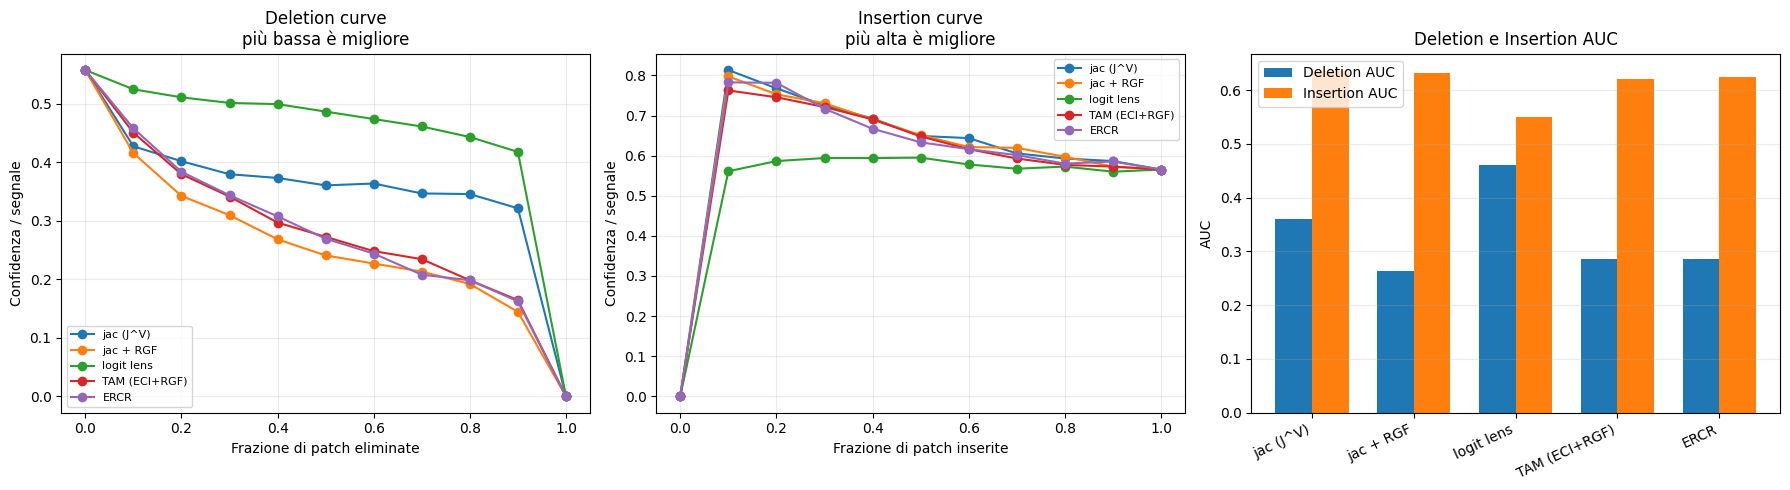

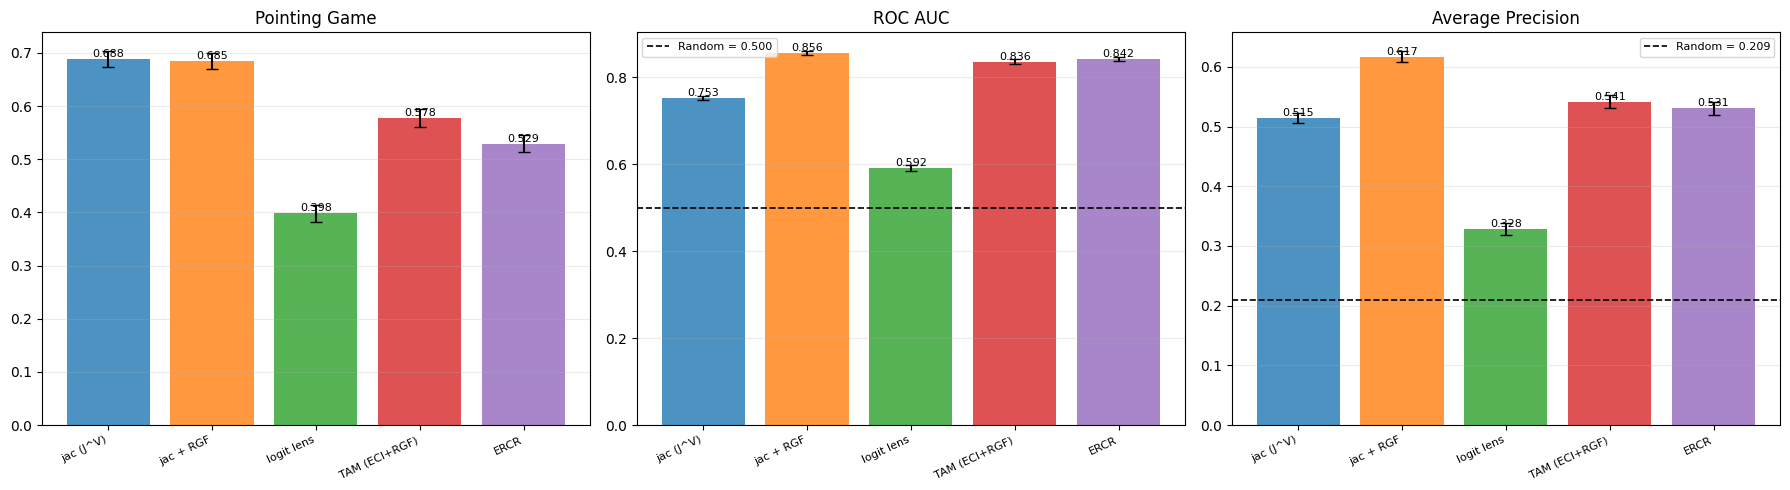

/tmp/ipykernel_3091222/2961746340.py:679: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = axis.boxplot(
/tmp/ipykernel_3091222/2961746340.py:679: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = axis.boxplot(


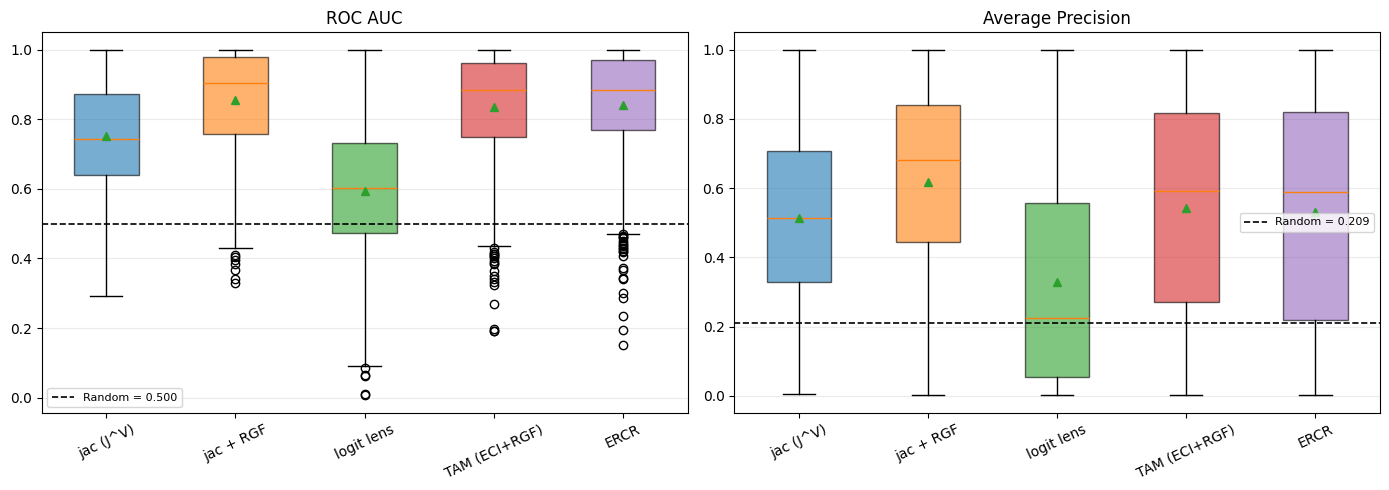

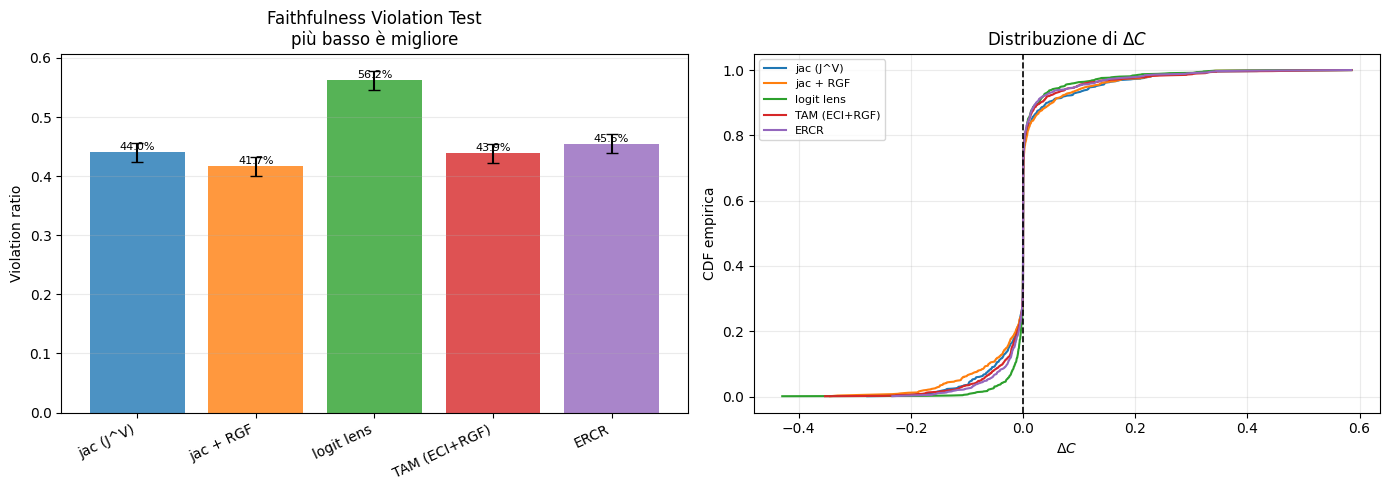


NUMERO DI CAMPIONI PER METRICA


,Metodo,N Pointing,N ROC,N AP,N Violation,N Deletion,N Insertion
0,jac (J^V),907,827,846,943,943,943
1,jac + RGF,907,827,846,943,943,943
2,logit lens,907,827,846,943,943,943
3,TAM (ECI+RGF),907,827,846,943,943,943
4,ERCR,907,827,846,943,943,943



Visualizzazione completata. Nessun file è stato salvato.


In [5]:
# ============================================================
# CARICAMENTO E VISUALIZZAZIONE DEI RISULTATI ESISTENTI
#
# Non esegue il modello.
# Non ricalcola le metriche.
# Non salva alcun file.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display


# ============================================================
# 1. CERCA IL FILE DEI RISULTATI
# ============================================================

result_path = Path("task2_compare_TAM_ERCR/task2_final.pt")


# ============================================================
# 2. CARICA IL CHECKPOINT
# ============================================================

try:
    saved = torch.load(
        result_path,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    saved = torch.load(
        result_path,
        map_location="cpu"
    )

if not isinstance(saved, dict):
    raise TypeError(
        "Il file caricato non contiene un dizionario di risultati."
    )

if "results" not in saved:
    raise KeyError(
        "Nel file non è presente la chiave `results`.\n"
        f"Chiavi disponibili: {list(saved.keys())}"
    )

results = saved["results"]
pairs = saved.get("pairs", [])
prevalence = saved.get("prevalence", [])
skipped = saved.get("skipped", [])


# ============================================================
# 3. FUNZIONI DI SUPPORTO
# ============================================================

def finite_array(values):
    """Converte i valori in un array numerico finito."""
    if values is None:
        return np.asarray([], dtype=float)

    try:
        array = np.asarray(values, dtype=float).reshape(-1)
    except (TypeError, ValueError):
        return np.asarray([], dtype=float)

    return array[np.isfinite(array)]


def safe_mean(values):
    array = finite_array(values)
    return float(array.mean()) if array.size else np.nan


def safe_sem(values):
    array = finite_array(values)

    if array.size <= 1:
        return np.nan

    return float(
        array.std(ddof=1) / np.sqrt(array.size)
    )


def safe_count(values):
    return int(finite_array(values).size)


def get_metric(method, key):
    return results.get(method, {}).get(key, [])


def format_mean_sem(mean, sem, percentage=False):
    if not np.isfinite(mean):
        return "n/d"

    if percentage:
        if np.isfinite(sem):
            return f"{mean:.1%} ± {sem:.1%}"
        return f"{mean:.1%}"

    if np.isfinite(sem):
        return f"{mean:.3f} ± {sem:.3f}"

    return f"{mean:.3f}"


# ============================================================
# 4. ORDINE DEI METODI
# ============================================================

preferred_order = [
    "jac (J^V)",
    "jac + RGF",
    "logit lens",
    "TAM (ECI+RGF)",
    "ERCR",
]

method_order = [
    method
    for method in preferred_order
    if method in results
]

method_order += [
    method
    for method in results
    if method not in method_order
]

if not method_order:
    raise ValueError(
        "La chiave `results` è presente ma non contiene metodi."
    )

print("\nMetodi trovati:")
for method in method_order:
    print(" -", method)


# ============================================================
# 5. COSTRUISCE LA TABELLA
# ============================================================

rows = []

for method in method_order:
    rows.append({
        "Metodo": method,

        "Pointing Game ↑":
            safe_mean(get_metric(method, "point")),
        "Pointing SEM":
            safe_sem(get_metric(method, "point")),

        "ROC AUC ↑":
            safe_mean(get_metric(method, "roc")),
        "ROC SEM":
            safe_sem(get_metric(method, "roc")),

        "AP ↑":
            safe_mean(get_metric(method, "ap")),
        "AP SEM":
            safe_sem(get_metric(method, "ap")),

        "Violation Test ↓":
            safe_mean(get_metric(method, "fvt_viol")),
        "Violation SEM":
            safe_sem(get_metric(method, "fvt_viol")),

        "ΔC medio ↑":
            safe_mean(get_metric(method, "fvt_dC")),
        "ΔC SEM":
            safe_sem(get_metric(method, "fvt_dC")),

        "Deletion AUC ↓":
            safe_mean(get_metric(method, "del_auc")),
        "Deletion SEM":
            safe_sem(get_metric(method, "del_auc")),

        "Insertion AUC ↑":
            safe_mean(get_metric(method, "ins_auc")),
        "Insertion SEM":
            safe_sem(get_metric(method, "ins_auc")),

        "N Pointing":
            safe_count(get_metric(method, "point")),
        "N ROC":
            safe_count(get_metric(method, "roc")),
        "N AP":
            safe_count(get_metric(method, "ap")),
        "N Violation":
            safe_count(get_metric(method, "fvt_viol")),
        "N Deletion":
            safe_count(get_metric(method, "del_auc")),
        "N Insertion":
            safe_count(get_metric(method, "ins_auc")),
    })

df_final = pd.DataFrame(rows)


# ============================================================
# 6. BASELINE CASUALI
# ============================================================

random_roc = 0.5

prevalence_array = finite_array(prevalence)

random_ap = (
    float(prevalence_array.mean())
    if prevalence_array.size
    else np.nan
)

print("\n" + "=" * 105)
print("RISULTATI FINALI")
print("=" * 105)

if len(pairs):
    print(f"Coppie valutate: {len(pairs)}")

if len(skipped):
    print(f"Coppie scartate: {len(skipped)}")

print(f"Baseline casuale ROC AUC: {random_roc:.3f}")

if np.isfinite(random_ap):
    print(f"Baseline casuale AP:      {random_ap:.3f}")


# ============================================================
# 7. TABELLA PRINCIPALE
# ============================================================

main_columns = [
    "Metodo",
    "Pointing Game ↑",
    "ROC AUC ↑",
    "AP ↑",
    "Violation Test ↓",
    "Deletion AUC ↓",
    "Insertion AUC ↑",
]

display(
    df_final[main_columns]
    .style
    .format(
        {
            "Pointing Game ↑": "{:.3f}",
            "ROC AUC ↑": "{:.3f}",
            "AP ↑": "{:.3f}",
            "Violation Test ↓": "{:.1%}",
            "Deletion AUC ↓": "{:.3f}",
            "Insertion AUC ↑": "{:.3f}",
        },
        na_rep="n/d"
    )
    .highlight_max(
        subset=[
            "Pointing Game ↑",
            "ROC AUC ↑",
            "AP ↑",
            "Insertion AUC ↑",
        ],
        props="font-weight: bold; background-color: #d9ead3;"
    )
    .highlight_min(
        subset=[
            "Violation Test ↓",
            "Deletion AUC ↓",
        ],
        props="font-weight: bold; background-color: #d9ead3;"
    )
)


# ============================================================
# 8. TABELLA MEDIA ± SEM
# ============================================================

df_report = pd.DataFrame({
    "Metodo": df_final["Metodo"],

    "Pointing Game": [
        format_mean_sem(mean, sem)
        for mean, sem in zip(
            df_final["Pointing Game ↑"],
            df_final["Pointing SEM"]
        )
    ],

    "ROC AUC": [
        format_mean_sem(mean, sem)
        for mean, sem in zip(
            df_final["ROC AUC ↑"],
            df_final["ROC SEM"]
        )
    ],

    "Average Precision": [
        format_mean_sem(mean, sem)
        for mean, sem in zip(
            df_final["AP ↑"],
            df_final["AP SEM"]
        )
    ],

    "Violation ratio": [
        format_mean_sem(mean, sem, percentage=True)
        for mean, sem in zip(
            df_final["Violation Test ↓"],
            df_final["Violation SEM"]
        )
    ],

    "ΔC medio": [
        format_mean_sem(mean, sem)
        for mean, sem in zip(
            df_final["ΔC medio ↑"],
            df_final["ΔC SEM"]
        )
    ],

    "Deletion AUC": [
        format_mean_sem(mean, sem)
        for mean, sem in zip(
            df_final["Deletion AUC ↓"],
            df_final["Deletion SEM"]
        )
    ],

    "Insertion AUC": [
        format_mean_sem(mean, sem)
        for mean, sem in zip(
            df_final["Insertion AUC ↑"],
            df_final["Insertion SEM"]
        )
    ],
})

print("\nMEDIA ± ERRORE STANDARD")
display(df_report)


# ============================================================
# 9. COLORI
# ============================================================

palette = plt.get_cmap("tab10")

method_colors = {
    method: palette(index % 10)
    for index, method in enumerate(method_order)
}


# ============================================================
# 10. CURVE DELETION E INSERTION
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

deletion_found = False
insertion_found = False

for method in method_order:
    deletion_curves = results[method].get(
        "del_curve",
        []
    )

    if len(deletion_curves):
        curves = np.asarray(
            deletion_curves,
            dtype=float
        )

        if curves.ndim == 2:
            mean_curve = np.nanmean(
                curves,
                axis=0
            )

            fractions = np.linspace(
                0,
                1,
                len(mean_curve)
            )

            axes[0].plot(
                fractions,
                mean_curve,
                marker="o",
                label=method,
                color=method_colors[method]
            )

            deletion_found = True

    insertion_curves = results[method].get(
        "ins_curve",
        []
    )

    if len(insertion_curves):
        curves = np.asarray(
            insertion_curves,
            dtype=float
        )

        if curves.ndim == 2:
            mean_curve = np.nanmean(
                curves,
                axis=0
            )

            fractions = np.linspace(
                0,
                1,
                len(mean_curve)
            )

            axes[1].plot(
                fractions,
                mean_curve,
                marker="o",
                label=method,
                color=method_colors[method]
            )

            insertion_found = True

axes[0].set_title(
    "Deletion curve\npiù bassa è migliore"
)
axes[0].set_xlabel(
    "Frazione di patch eliminate"
)
axes[0].set_ylabel(
    "Confidenza / segnale"
)
axes[0].grid(alpha=0.25)

if deletion_found:
    axes[0].legend(fontsize=8)
else:
    axes[0].text(
        0.5,
        0.5,
        "Curve deletion non presenti nel checkpoint",
        ha="center",
        va="center",
        transform=axes[0].transAxes
    )

axes[1].set_title(
    "Insertion curve\npiù alta è migliore"
)
axes[1].set_xlabel(
    "Frazione di patch inserite"
)
axes[1].set_ylabel(
    "Confidenza / segnale"
)
axes[1].grid(alpha=0.25)

if insertion_found:
    axes[1].legend(fontsize=8)
else:
    axes[1].text(
        0.5,
        0.5,
        "Curve insertion non presenti nel checkpoint",
        ha="center",
        va="center",
        transform=axes[1].transAxes
    )

# AUC deletion/insertion.
x = np.arange(len(method_order))
width = 0.36

deletion_auc = [
    safe_mean(get_metric(method, "del_auc"))
    for method in method_order
]

insertion_auc = [
    safe_mean(get_metric(method, "ins_auc"))
    for method in method_order
]

axes[2].bar(
    x - width / 2,
    deletion_auc,
    width,
    label="Deletion AUC"
)

axes[2].bar(
    x + width / 2,
    insertion_auc,
    width,
    label="Insertion AUC"
)

axes[2].set_xticks(x)
axes[2].set_xticklabels(
    method_order,
    rotation=25,
    ha="right"
)
axes[2].set_ylabel("AUC")
axes[2].set_title(
    "Deletion e Insertion AUC"
)
axes[2].legend()
axes[2].grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. POINTING GAME, ROC AUC E AP
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

specifications = [
    (
        "Pointing Game ↑",
        "Pointing SEM",
        "Pointing Game",
        np.nan
    ),
    (
        "ROC AUC ↑",
        "ROC SEM",
        "ROC AUC",
        random_roc
    ),
    (
        "AP ↑",
        "AP SEM",
        "Average Precision",
        random_ap
    ),
]

for axis, (
    metric,
    sem_metric,
    title,
    baseline
) in zip(axes, specifications):

    values = df_final[
        metric
    ].to_numpy(dtype=float)

    errors = (
        df_final[sem_metric]
        .fillna(0)
        .to_numpy(dtype=float)
    )

    bars = axis.bar(
        np.arange(len(method_order)),
        values,
        yerr=errors,
        capsize=4,
        color=[
            method_colors[method]
            for method in method_order
        ],
        alpha=0.8
    )

    if np.isfinite(baseline):
        axis.axhline(
            baseline,
            linestyle="--",
            color="black",
            linewidth=1.2,
            label=f"Random = {baseline:.3f}"
        )
        axis.legend(fontsize=8)

    for bar, value in zip(bars, values):
        if np.isfinite(value):
            axis.text(
                bar.get_x()
                + bar.get_width() / 2,
                value,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    axis.set_xticks(
        np.arange(len(method_order))
    )
    axis.set_xticklabels(
        method_order,
        rotation=25,
        ha="right",
        fontsize=8
    )
    axis.set_title(title)
    axis.grid(
        axis="y",
        alpha=0.25
    )

plt.tight_layout()
plt.show()


# ============================================================
# 12. BOXPLOT ROC AUC E AP
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for axis, key, title, baseline in [
    (axes[0], "roc", "ROC AUC", random_roc),
    (axes[1], "ap", "Average Precision", random_ap),
]:
    valid_methods = []
    values_list = []

    for method in method_order:
        values = finite_array(
            get_metric(method, key)
        )

        if values.size:
            valid_methods.append(method)
            values_list.append(values)

    if not values_list:
        axis.text(
            0.5,
            0.5,
            "Dati non disponibili",
            ha="center",
            va="center",
            transform=axis.transAxes
        )
        continue

    boxplot = axis.boxplot(
        values_list,
        labels=valid_methods,
        showmeans=True,
        patch_artist=True
    )

    for patch, method in zip(
        boxplot["boxes"],
        valid_methods
    ):
        patch.set_facecolor(
            method_colors[method]
        )
        patch.set_alpha(0.6)

    if np.isfinite(baseline):
        axis.axhline(
            baseline,
            linestyle="--",
            color="black",
            linewidth=1.2,
            label=f"Random = {baseline:.3f}"
        )
        axis.legend(fontsize=8)

    axis.set_title(title)
    axis.tick_params(
        axis="x",
        rotation=25
    )
    axis.grid(
        axis="y",
        alpha=0.25
    )

plt.tight_layout()
plt.show()


# ============================================================
# 13. VIOLATION TEST E CDF DI ΔC
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

violation_values = [
    safe_mean(
        get_metric(method, "fvt_viol")
    )
    for method in method_order
]

violation_sem = [
    safe_sem(
        get_metric(method, "fvt_viol")
    )
    for method in method_order
]

violation_sem = [
    value if np.isfinite(value) else 0
    for value in violation_sem
]

bars = axes[0].bar(
    np.arange(len(method_order)),
    violation_values,
    yerr=violation_sem,
    capsize=4,
    color=[
        method_colors[method]
        for method in method_order
    ],
    alpha=0.8
)

for bar, value in zip(
    bars,
    violation_values
):
    if np.isfinite(value):
        axes[0].text(
            bar.get_x()
            + bar.get_width() / 2,
            value,
            f"{value:.1%}",
            ha="center",
            va="bottom",
            fontsize=8
        )

axes[0].set_xticks(
    np.arange(len(method_order))
)
axes[0].set_xticklabels(
    method_order,
    rotation=25,
    ha="right"
)
axes[0].set_ylabel("Violation ratio")
axes[0].set_title(
    "Faithfulness Violation Test\n"
    "più basso è migliore"
)
axes[0].grid(
    axis="y",
    alpha=0.25
)

cdf_available = False

for method in method_order:
    delta_c = finite_array(
        get_metric(method, "fvt_dC")
    )

    if not delta_c.size:
        continue

    cdf_available = True

    sorted_values = np.sort(delta_c)

    cumulative = (
        np.arange(
            1,
            len(sorted_values) + 1
        )
        / len(sorted_values)
    )

    axes[1].plot(
        sorted_values,
        cumulative,
        label=method,
        color=method_colors[method]
    )

axes[1].axvline(
    0,
    linestyle="--",
    color="black",
    linewidth=1.2
)
axes[1].set_xlabel(r"$\Delta C$")
axes[1].set_ylabel("CDF empirica")
axes[1].set_title(
    r"Distribuzione di $\Delta C$"
)
axes[1].grid(alpha=0.25)

if cdf_available:
    axes[1].legend(fontsize=8)
else:
    axes[1].text(
        0.5,
        0.5,
        "Valori ΔC non disponibili",
        ha="center",
        va="center",
        transform=axes[1].transAxes
    )

plt.tight_layout()
plt.show()


# ============================================================
# 14. NUMERO DI CAMPIONI
# ============================================================

print("\nNUMERO DI CAMPIONI PER METRICA")

display(
    df_final[
        [
            "Metodo",
            "N Pointing",
            "N ROC",
            "N AP",
            "N Violation",
            "N Deletion",
            "N Insertion",
        ]
    ]
)

print("\nVisualizzazione completata. Nessun file è stato salvato.")